# 03 — Validação dos Dados do SINAN

## Objetivo

Este notebook tem como objetivo avaliar a qualidade dos dados do SINAN após a etapa de pré-processamento, considerando as variáveis prioritárias selecionadas para as análises epidemiológicas e para a posterior geração dos documentos semânticos.

A validação é realizada considerando três dimensões principais da qualidade dos dados:

### 1. Completude

Avalia a presença ou ausência de valores nas variáveis prioritárias.

Para cada variável são calculados:

- total de registros;
- total de registros preenchidos;
- total de registros ausentes;
- percentual de completude;
- percentual de incompletude;
- classificação da incompletude.

A ausência de informação não é considerada, por si só, um valor inválido. Dessa forma, completude e validade são avaliadas separadamente.

### 2. Validade

Avalia se os valores preenchidos pertencem ao domínio esperado para cada variável.

As regras de validade são definidas de acordo com a natureza da variável, podendo envolver:

- domínios categóricos definidos pelo dicionário de dados do SINAN;
- intervalos numéricos permitidos;
- formatos esperados;
- códigos geográficos padronizados;
- tabelas de referência externas.

Por exemplo, para a variável `SOROTIPO`, são considerados válidos os códigos `1`, `2`, `3` e `4`.

Um valor ausente (`NaN`) não é classificado como inválido, pois sua ausência é tratada na avaliação de completude.

### 3. Consistência

Avalia a coerência entre variáveis relacionadas.

Entre as verificações consideradas estão:

- compatibilidade entre ano e semana epidemiológica;
- compatibilidade entre código e nome da UF;
- compatibilidade entre UF e município;
- coerência entre campos relacionados à autoctonia e à provável fonte de infecção.

Dessa forma, um valor pode ser individualmente válido quanto ao domínio, mas apresentar inconsistência quando relacionado a outro campo.

---

## Variáveis prioritárias (escolhidas para serem utilizadas nos documentos finais)

As variáveis avaliadas são organizadas nos seguintes grupos:

- variáveis estruturais;
- variáveis epidemiológicas;
- sinais clínicos;
- doenças preexistentes;
- autoctonia;
- provável fonte de infecção.

A definição explícita dessas variáveis permite concentrar a avaliação da qualidade nos atributos utilizados nas etapas posteriores do pipeline.

---

## Tratamento dos problemas de qualidade

A identificação de valores ausentes, inválidos ou inconsistentes não implica automaticamente a exclusão do registro.

Sempre que possível, os dados originais são preservados e os problemas identificados são registrados por meio de indicadores de qualidade.

Essa estratégia permite distinguir:

- **ausência** → problema de completude;
- **valor fora do domínio** → problema de validade;
- **incompatibilidade entre campos** → problema de consistência.

Essa separação contribui para a rastreabilidade das transformações realizadas no pipeline.

---

## Saídas do notebook

A principal saída desta etapa é o conjunto de dados validado:

`sinan_2026_validado.parquet`

Esse arquivo preserva os registros epidemiológicos e pode incorporar indicadores produzidos durante a validação. Ele será utilizado como entrada para o notebook `04_enriquecimento_SINAN.ipynb`.

Também são produzidos relatórios auxiliares de qualidade, contendo informações como:

- completude das variáveis prioritárias;
- validade dos domínios;
- valores identificados fora dos domínios esperados;
- inconsistências identificadas durante as verificações.

Esses relatórios são utilizados para análise da qualidade dos dados e documentação metodológica, não constituindo a entrada principal da etapa de enriquecimento.

---

## Fluxo da etapa
```
02_preprocessamento_SINAN

↓  

03_validacao_SINAN

↓  

sinan_2026_validado.parquet

↓  

04_enriquecimento_SINAN
```

A etapa de validação, portanto, funciona como uma camada de controle de qualidade entre o pré-processamento dos registros do SINAN e o enriquecimento dos dados com fontes externas.

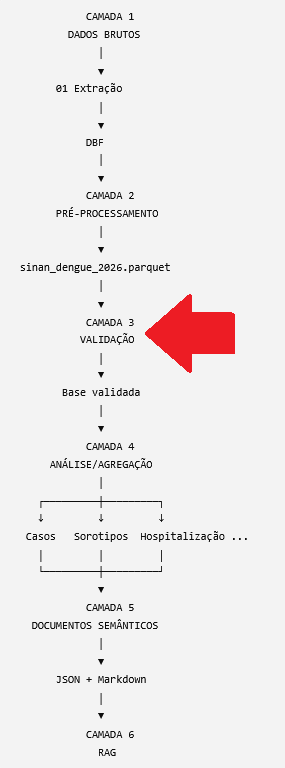

## Validação dos domínios das variáveis categóricas

Além da análise de valores ausentes, é necessário verificar se os códigos presentes nas variáveis categóricas pertencem aos domínios definidos pelo dicionário de dados do SINAN.

Nesta análise, são consideradas quatro situações distintas:

- **Valor válido:** código pertencente ao domínio definido pelo SINAN e com interpretação conhecida.
- **Valor ignorado:** código explicitamente definido no dicionário como "Ignorado", como o valor `9` em determinadas variáveis.
- **Valor ausente:** ausência de informação no campo, representada por valor nulo (`NaN`/`NA`).
- **Valor fora do domínio:** valor presente no arquivo, mas não previsto entre os códigos definidos pelo dicionário de dados utilizado.

Foram identificados registros com código `0` nas variáveis `SOROTIPO`, `HOSPITALIZ` e `EVOLUCAO`. Como esse código não está definido nos respectivos domínios do dicionário consultado, esses registros são considerados **fora do domínio esperado**, e não são automaticamente interpretados como "Ignorado" ou como uma categoria epidemiológica válida.

Para preservar a rastreabilidade, os valores originais são mantidos no conjunto de dados processado. Nas análises epidemiológicas, entretanto, somente os códigos pertencentes aos domínios definidos são considerados valores válidos.

Essa distinção também permite diferenciar **percentual de valores ausentes** de **cobertura válida da informação**. Por exemplo, uma variável pode apresentar registros não nulos que, por conterem códigos fora do domínio, não devem ser considerados informação epidemiologicamente válida.

Esse tratamento é particularmente importante para a variável `SOROTIPO`, cuja interpretação deve considerar a quantidade de registros com sorotipo efetivamente identificado, evitando generalizações da distribuição observada para registros sem informação válida.

Ver arquivo de dicionário de dados em G:\Meu Drive\Doutorado\arbovirus_rag\data_docs\SINAN

# Montagem do drive

In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


# 1 - Configuração das pastas

In [2]:
from pathlib import Path
import pandas as pd

# ============================================================
# CONFIGURAÇÕES
# ============================================================

ANO = 2026

PASTA_PROJETO = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

PASTA_PROCESSED = (
    PASTA_PROJETO
    / "data_processed"
    / "SINAN"
    / str(ANO)
)

ARQUIVO_PROCESSADO = (
    PASTA_PROCESSED
    / f"sinan_dengue_{ANO}_preprocessado.parquet"
)

# ============================================================
# DIRETÓRIO DOS RESULTADOS DE VALIDAÇÃO
# ============================================================

PASTA_VALIDACAO = (
    PASTA_PROCESSED
    / "validacao"
)

PASTA_VALIDACAO.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Resultados de validação: {PASTA_VALIDACAO}"
)

# ============================================================
# DIRETÓRIO DOS RELATÓRIOS DE QUALIDADE
# ============================================================

PASTA_RELATORIOS = (
    Path(
        "/content/drive/MyDrive/Doutorado/"
        "arbovirus_rag/reports/SINAN"
    )
    / str(ANO)
)

PASTA_RELATORIOS.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Pasta de relatórios:\n"
    f"{PASTA_RELATORIOS}"
)

# ============================================================
# VERIFICAÇÃO
# ============================================================

if not ARQUIVO_PROCESSADO.is_file():
    raise FileNotFoundError(
        f"Arquivo processado não encontrado: "
        f"{ARQUIVO_PROCESSADO}"
    )

# ============================================================
# CARREGAMENTO
# ============================================================

df = pd.read_parquet(
    ARQUIVO_PROCESSADO
)

print("Dados processados carregados.")
print(f"Registros: {len(df):,}")
print(f"Colunas: {len(df.columns)}")

Resultados de validação: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/validacao
Pasta de relatórios:
/content/drive/MyDrive/Doutorado/arbovirus_rag/reports/SINAN/2026
Dados processados carregados.
Registros: 444,266
Colunas: 152


A validação dos dados abrage as seguintes dimensões:


| Dimensão                | Pergunta                                 |
| ----------------------- | ---------------------------------------- |
| **Completude**          | O campo está preenchido?                 |
| **Validade de domínio** | O valor preenchido é permitido?          |
| **Consistência**        | O valor é coerente com os demais campos? |

Exemplo de consistência:

* Caso autóctone = Sim
* UF provável de infecção = 52
* Município provável = Goiânia

Os três valores podem ser individualmente válidos. Mas ainda podemos perguntar se eles são coerentes entre si e com o município/UF de residência ou notificação, conforme a definição epidemiológica aplicável.
Ou:

* UF provável da fonte = 52  (Goiás)
* Município provável = 355030 (São Paulo)

Ambos são códigos válidos isoladamente, mas a combinação é inconsistente.

# 2 - Cobertura das UFs

In [3]:
# ============================================================
# COBERTURA DAS UNIDADES FEDERATIVAS
# ============================================================

ufs = (
    df[
        ["SG_UF_NOT", "UF_NAME"]
    ]
    .drop_duplicates()
    .sort_values("SG_UF_NOT")
)

display(ufs)

print(
    f"Quantidade de UFs: "
    f"{df['SG_UF_NOT'].nunique()}"
)

,SG_UF_NOT,UF_NAME
20026,11,Rondônia
19276,12,Acre
26514,13,Amazonas
352502,14,Roraima
27131,15,Pará
27951,16,Amapá
27689,17,Tocantins
30222,21,Maranhão
19992,22,Piauí
26660,23,Ceará


Quantidade de UFs: 27


Cobertura temporal

In [4]:
# ============================================================
# COBERTURA TEMPORAL
# ============================================================

print(f"Ano esperado: {ANO}")

print(
    "Anos encontrados:",
    sorted(
        df["NU_ANO"]
        .dropna()
        .unique()
    )
)

print(
    "Semana inicial:",
    df["SEMANA_EPIDEMIOLOGICA"].min()
)

print(
    "Semana final:",
    df["SEMANA_EPIDEMIOLOGICA"].max()
)

Ano esperado: 2026
Anos encontrados: [np.int64(2026)]
Semana inicial: 1
Semana final: 34


Verificação de incompletude

In [5]:
# ============================================================
# CLASSIFICAÇÃO DA INCOMPLETUDE
# ============================================================

# Define the 'qualidade' DataFrame by calculating missing percentages for all columns in 'df'
dados_qualidade = []
for coluna in df.columns:
    percentual_ausentes = df[coluna].isna().mean() * 100
    dados_qualidade.append({
        "VARIAVEL": coluna,
        "PERCENTUAL_AUSENTES": percentual_ausentes
    })
qualidade = pd.DataFrame(dados_qualidade)

def classificar_incompletude(percentual):

    if percentual == 0:
        return "Sem ausência"

    elif percentual < 5:
        return "Muito baixa"

    elif percentual < 20:
        return "Baixa"

    elif percentual < 50:
        return "Moderada"

    elif percentual < 80:
        return "Alta"

    else:
        return "Muito alta"


qualidade["CLASSIFICACAO"] = (
    qualidade["PERCENTUAL_AUSENTES"]
    .apply(classificar_incompletude)
)

display(
    qualidade
)

,VARIAVEL,PERCENTUAL_AUSENTES,CLASSIFICACAO
0,TP_NOT,0.000000,Sem ausência
1,ID_AGRAVO,0.000000,Sem ausência
2,DT_NOTIFIC,0.000000,Sem ausência
3,SEM_NOT,0.000000,Sem ausência
4,NU_ANO,0.000000,Sem ausência
...,...,...,...
147,RENAL_DECODED,3.510960,Muito baixa
148,HIPERTENSA_DECODED,3.511185,Muito baixa
149,ACIDO_PEPT_DECODED,3.510960,Muito baixa
150,AUTO_IMUNE_DECODED,3.510960,Muito baixa


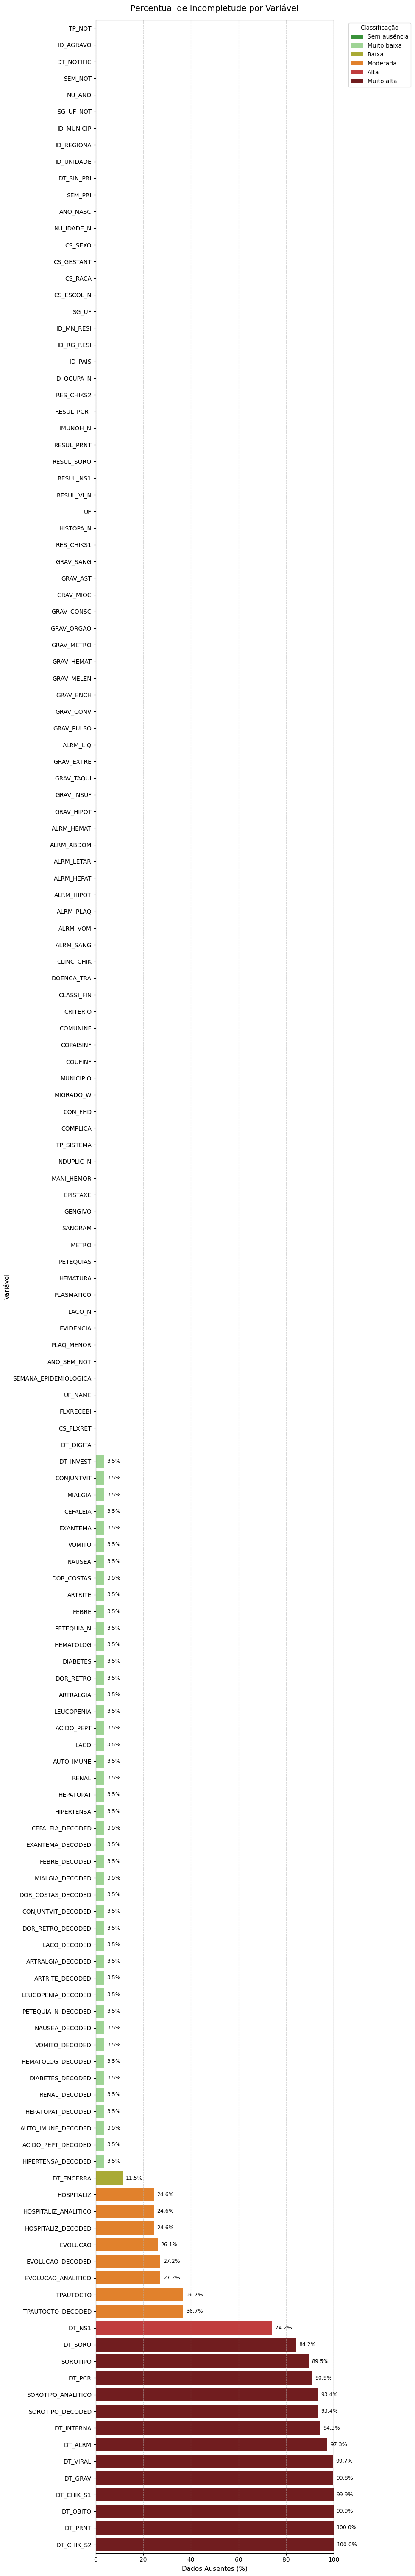

In [6]:
# ============================================================
# GRÁFICO DE INCOMPLETUDE DAS COLUNAS DO SINAN PREPROCESSADO GERADO PELO NOTEBOOK 02
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ordenar o DataFrame pelo percentual
qualidade_ordenada = qualidade.sort_values(
    by="PERCENTUAL_AUSENTES", ascending=True
)

# 2. Paleta de cores semântica para as categorias
paleta = {
    "Sem ausência": "#2ca02c",  # Verde
    "Muito baixa": "#98df8a",  # Verde claro
    "Baixa": "#bcbd22",  # Amarelo-esverdeado
    "Moderada": "#ff7f0e",  # Laranja
    "Alta": "#d62728",  # Vermelho
    "Muito alta": "#7f0f12",  # Vinho/Escuro
}

# 3. Configurar figura
plt.figure(
    figsize=(10, max(4, len(qualidade) * 0.4))
)  # Ajusta a altura automaticamente

ax = sns.barplot(
    data=qualidade_ordenada,
    x="PERCENTUAL_AUSENTES",
    y="VARIAVEL",
    hue="CLASSIFICACAO",
    palette=paleta,
    dodge=False,
)

# 4. Rótulos e limites
plt.title("Percentual de Incompletude por Variável", fontsize=14, pad=15)
plt.xlabel("Dados Ausentes (%)", fontsize=11)
plt.ylabel("Variável", fontsize=11)
plt.xlim(0, 100)

# Adicionar o valor exato no final de cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.1f}%",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=9,
        )

plt.legend(title="Classificação", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Na célula abaixo categorizamos as variáveis que iremos utilizar

In [7]:
# ============================================================
# VARIÁVEIS PRIORITÁRIAS PARA VALIDAÇÃO
# ============================================================

VARIAVEIS_ESTRUTURAIS = [
    "NU_ANO",
    "SEM_NOT",
    "SEMANA_EPIDEMIOLOGICA",
    "SG_UF_NOT",
    "UF_NAME",
    "ID_MUNICIP"
]


VARIAVEIS_EPIDEMIOLOGICAS = [
    "SOROTIPO",
    "HOSPITALIZ",
    "EVOLUCAO"
]


VARIAVEIS_SINAIS_CLINICOS = [
    "FEBRE",
    "MIALGIA",
    "CEFALEIA",
    "EXANTEMA",
    "VOMITO",
    "NAUSEA",
    "DOR_COSTAS",
    "CONJUNTVIT",
    "ARTRITE",
    "ARTRALGIA",
    "PETEQUIA_N",
    "LEUCOPENIA",
    "LACO",
    "DOR_RETRO"
]


VARIAVEIS_DOENCAS_PREEXISTENTES = [
    "DIABETES",
    "HEMATOLOG",
    "HEPATOPAT",
    "RENAL",
    "HIPERTENSA",
    "ACIDO_PEPT",
    "AUTO_IMUNE"
]


VARIAVEIS_AUTOCTONIA = [
    "TPAUTOCTO"
]


VARIAVEIS_FONTE_INFECCAO = [
    "COUFINF",
    "COMUNINF"
]
VARIAVEIS_PRIORITARIAS = (
    VARIAVEIS_ESTRUTURAIS
    + VARIAVEIS_EPIDEMIOLOGICAS
    + VARIAVEIS_SINAIS_CLINICOS
    + VARIAVEIS_DOENCAS_PREEXISTENTES
    + VARIAVEIS_AUTOCTONIA
    + VARIAVEIS_FONTE_INFECCAO
)
print(
    "Total de variáveis prioritárias:",
    len(VARIAVEIS_PRIORITARIAS)
)

Total de variáveis prioritárias: 33


A qualidade das variáveis prioritárias é avaliada de acordo com a dimensão de completude.

In [8]:
# ============================================================
# QUALIDADE DAS VARIÁVEIS PRIORITÁRIAS
# ============================================================

qualidade_prioritaria = (
    qualidade[
        qualidade["VARIAVEL"]
        .isin(VARIAVEIS_PRIORITARIAS)
    ]
    .copy()
)

display(
    qualidade_prioritaria
)

,VARIAVEL,PERCENTUAL_AUSENTES,CLASSIFICACAO
3,SEM_NOT,0.000000,Sem ausência
4,NU_ANO,0.000000,Sem ausência
5,SG_UF_NOT,0.000000,Sem ausência
6,ID_MUNICIP,0.000000,Sem ausência
23,FEBRE,3.509834,Muito baixa
24,MIALGIA,3.509834,Muito baixa
25,CEFALEIA,3.509834,Muito baixa
26,EXANTEMA,3.509834,Muito baixa
27,VOMITO,3.509834,Muito baixa
28,NAUSEA,3.509834,Muito baixa


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Dicionário de mapeamento das listas para categorias
mapa_grupos = {}
grupos_dict = {
    "Estruturais": VARIAVEIS_ESTRUTURAIS,
    "Epidemiológicas": VARIAVEIS_EPIDEMIOLOGICAS,
    "Sinais Clínicos": VARIAVEIS_SINAIS_CLINICOS,
    "Doenças Preexistentes": VARIAVEIS_DOENCAS_PREEXISTENTES,
    "Autoctonia": VARIAVEIS_AUTOCTONIA,
    "Fonte de Infecção": VARIAVEIS_FONTE_INFECCAO,
}

for grupo, variaveis in grupos_dict.items():
    for var in variaveis:
        mapa_grupos[var] = grupo

qualidade_prioritaria["GRUPO"] = qualidade_prioritaria["VARIAVEL"].map(
    mapa_grupos
)

Gráfico de incompletude das variáveis prioritárias

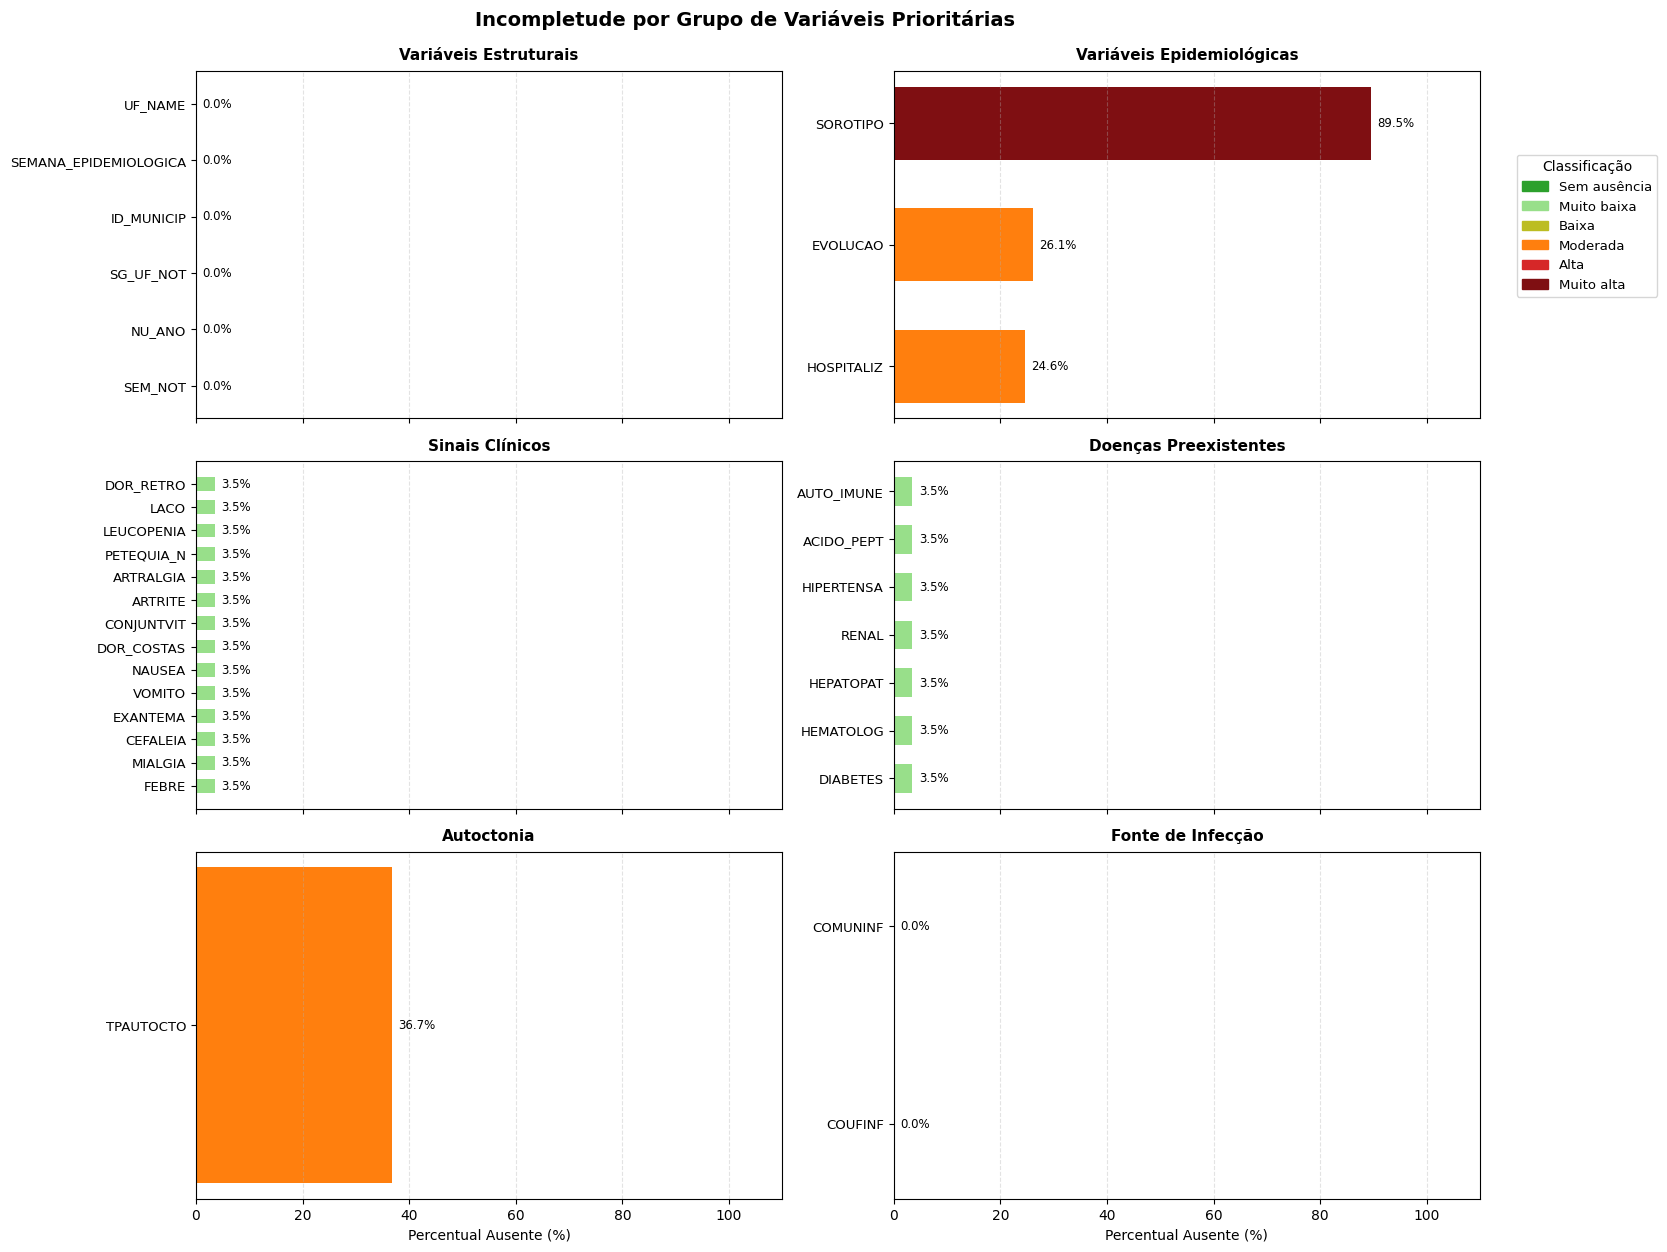

In [10]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. MAPEAMENTO DAS CATEGORIAS NAS VARIÁVEIS
# ============================================================
grupos_dict = {
    "Variáveis Estruturais": VARIAVEIS_ESTRUTURAIS,
    "Variáveis Epidemiológicas": VARIAVEIS_EPIDEMIOLOGICAS,
    "Sinais Clínicos": VARIAVEIS_SINAIS_CLINICOS,
    "Doenças Preexistentes": VARIAVEIS_DOENCAS_PREEXISTENTES,
    "Autoctonia": VARIAVEIS_AUTOCTONIA,
    "Fonte de Infecção": VARIAVEIS_FONTE_INFECCAO,
}

mapa_grupos = {}
for grupo, variaveis in grupos_dict.items():
    for var in variaveis:
        mapa_grupos[var] = grupo

qualidade_prioritaria["GRUPO"] = qualidade_prioritaria["VARIAVEL"].map(
    mapa_grupos
)

# ============================================================
# 2. PALETA DE CORES SEMÂNTICA
# ============================================================
paleta_incompletude = {
    "Sem ausência": "#2ca02c",
    "Muito baixa": "#98df8a",
    "Baixa": "#bcbd22",
    "Moderada": "#ff7f0e",
    "Alta": "#d62728",
    "Muito alta": "#7f0f12",
}

# ============================================================
# 3. CRIAÇÃO DA GRADE DE SUBPLOTS (2 COLUNAS)
# ============================================================
grupos_unicos = [g for g in grupos_dict.keys() if g in qualidade_prioritaria["GRUPO"].unique()]
n_grupos = len(grupos_unicos)
n_cols = 2
n_rows = (n_grupos + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4.2), sharex=True)
axes = axes.flatten()

# ============================================================
# 4. PLOT DE CADA GRUPO COM OS NOMES DAS VARIÁVEIS NO EIXO Y
# ============================================================
for i, grupo in enumerate(grupos_unicos):
    ax = axes[i]
    dados_grupo = (
        qualidade_prioritaria[qualidade_prioritaria["GRUPO"] == grupo]
        .sort_values(by="PERCENTUAL_AUSENTES", ascending=True)
        .reset_index(drop=True)
    )

    cores = [paleta_incompletude.get(c, "#333333") for c in dados_grupo["CLASSIFICACAO"]]
    posicoes_y = range(len(dados_grupo))

    # Barras horizontais
    barras = ax.barh(
        posicoes_y,
        dados_grupo["PERCENTUAL_AUSENTES"],
        color=cores,
        height=0.6,
        edgecolor="none",
    )

    # Nomes das variáveis no eixo Y
    ax.set_yticks(posicoes_y)
    ax.set_yticklabels(dados_grupo["VARIAVEL"], fontsize=9.5)
    ax.set_title(f"{grupo}", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlim(0, 110)
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    # Rótulo com a porcentagem ao lado da barra
    for barra, valor in zip(barras, dados_grupo["PERCENTUAL_AUSENTES"]):
        ax.text(
            valor + 1.2,
            barra.get_y() + barra.get_height() / 2.0,
            f"{valor:.1f}%",
            va="center",
            ha="left",
            fontsize=8.5,
        )

# Ocultar eixos vazios (caso o número de grupos seja ímpar)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Rótulo comum no eixo X para a última linha
for ax in axes[-n_cols:]:
    ax.set_xlabel("Percentual Ausente (%)", fontsize=10)

# ============================================================
# 5. LEGENDA GLOBAL E TÍTULO PRINCIPAL
# ============================================================
handles = [
    mpatches.Patch(color=cor, label=cat)
    for cat, cor in paleta_incompletude.items()
]
fig.legend(
    handles=handles,
    title="Classificação",
    bbox_to_anchor=(1.01, 0.88),
    loc="upper left",
    frameon=True,
    fontsize=9.5,
)

fig.suptitle(
    "Incompletude por Grupo de Variáveis Prioritárias",
    fontsize=14,
    fontweight="bold",
    y=0.99,
)

plt.tight_layout()
plt.show()

Abaixo geramos um gráfico

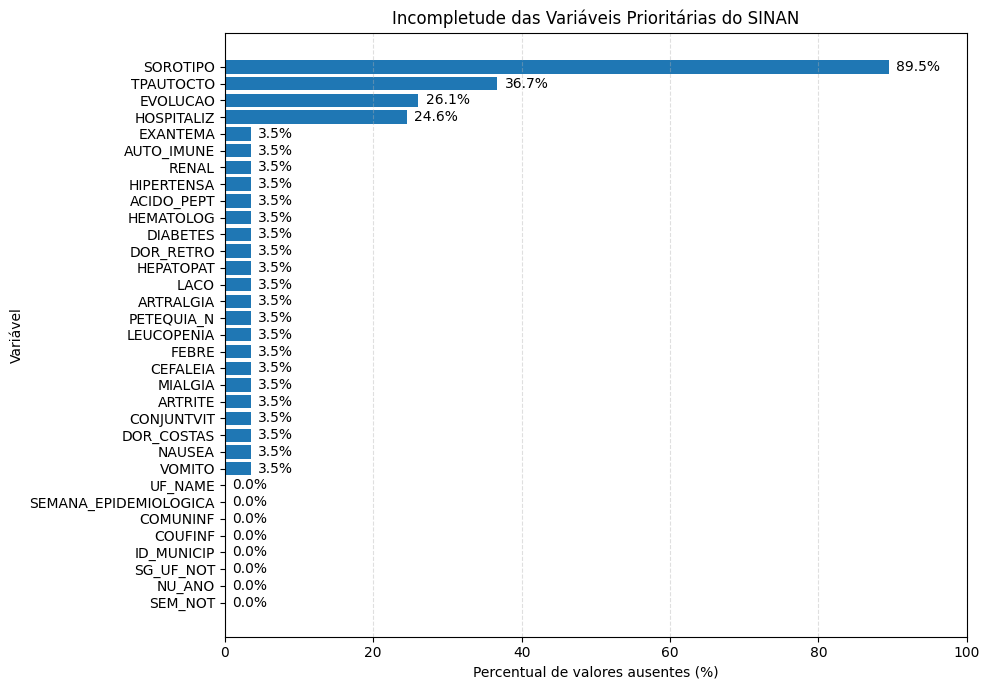

In [11]:
# ============================================================
# GRÁFICO DE INCOMPLETUDE DAS VARIÁVEIS PRIORITÁRIAS
# ============================================================

import matplotlib.pyplot as plt

# Ordenar da menor para a maior incompletude
qualidade_grafico = (
    qualidade_prioritaria
    .sort_values(
        "PERCENTUAL_AUSENTES",
        ascending=True
    )
    .copy()
)

plt.figure(figsize=(10, 7))

barras = plt.barh(
    qualidade_grafico["VARIAVEL"],
    qualidade_grafico["PERCENTUAL_AUSENTES"]
)

plt.xlabel("Percentual de valores ausentes (%)")
plt.ylabel("Variável")
plt.title(
    "Incompletude das Variáveis Prioritárias do SINAN"
)

plt.xlim(
    0,
    max(
        100,
        qualidade_grafico["PERCENTUAL_AUSENTES"].max() + 5
    )
)

# Adicionar rótulos nas barras
for barra, percentual in zip(
    barras,
    qualidade_grafico["PERCENTUAL_AUSENTES"]
):
    plt.text(
        barra.get_width() + 1,
        barra.get_y() + barra.get_height() / 2,
        f"{percentual:.1f}%",
        va="center"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

É importante detalhar melhor a completude, por exemplo, registros informados, registros ausentes.

Na célula abaixo é realizada uma avaliação da completude DE TODAS AS COLUNAS DO DATAFRAME. A classificação é:
* sem ausência
* muito baixa
* baixa
* moderada
* alta
* muito alta

In [12]:
# ============================================================
# AVALIAÇÃO DA COMPLETUDE / INCOMPLETUDE DO ARQUIVO PREPROCESSADO MAIS DETALHADO
# ============================================================

dados_qualidade = []

total_registros = len(df)

for coluna in df.columns:

    total_ausentes = df[coluna].isna().sum()
    total_preenchidos = df[coluna].notna().sum()

    percentual_ausentes = (
        total_ausentes
        / total_registros
        * 100
    )

    percentual_preenchidos = (
        total_preenchidos
        / total_registros
        * 100
    )

    dados_qualidade.append({
        "VARIAVEL": coluna,
        "TOTAL_REGISTROS": total_registros,
        "TOTAL_PREENCHIDOS": total_preenchidos,
        "TOTAL_AUSENTES": total_ausentes,
        "PERCENTUAL_PREENCHIDOS": percentual_preenchidos,
        "PERCENTUAL_AUSENTES": percentual_ausentes
    })


# ============================================================
# CRIAÇÃO DO DATAFRAME
# ============================================================

qualidade = pd.DataFrame(dados_qualidade)


# ============================================================
# CLASSIFICAÇÃO DA INCOMPLETUDE
# ============================================================

qualidade["CLASSIFICACAO"] = (
    qualidade["PERCENTUAL_AUSENTES"]
    .apply(classificar_incompletude)
)


# ============================================================
# VISUALIZAÇÃO
# ============================================================

display(qualidade)

,VARIAVEL,TOTAL_REGISTROS,TOTAL_PREENCHIDOS,TOTAL_AUSENTES,PERCENTUAL_PREENCHIDOS,PERCENTUAL_AUSENTES,CLASSIFICACAO
0,TP_NOT,444266,444266,0,100.000000,0.000000,Sem ausência
1,ID_AGRAVO,444266,444266,0,100.000000,0.000000,Sem ausência
2,DT_NOTIFIC,444266,444266,0,100.000000,0.000000,Sem ausência
3,SEM_NOT,444266,444266,0,100.000000,0.000000,Sem ausência
4,NU_ANO,444266,444266,0,100.000000,0.000000,Sem ausência
...,...,...,...,...,...,...,...
147,RENAL_DECODED,444266,428668,15598,96.489040,3.510960,Muito baixa
148,HIPERTENSA_DECODED,444266,428667,15599,96.488815,3.511185,Muito baixa
149,ACIDO_PEPT_DECODED,444266,428668,15598,96.489040,3.510960,Muito baixa
150,AUTO_IMUNE_DECODED,444266,428668,15598,96.489040,3.510960,Muito baixa


Na célula abaixo é realizada uma avaliação da completude APENAS DAS VARIÁVEIS PRIORITÁRIAS (QUE IREMOS TRABALHAR). A classificação é:
* sem ausência
* muito baixa
* baixa
* moderada
* alta
* muito alta

In [13]:
# ============================================================
# QUALIDADE (COMPLETUDE) DAS VARIÁVEIS PRIORITÁRIAS MAIS DETALHADO
# ============================================================

qualidade_prioritaria = (
    qualidade[
        qualidade["VARIAVEL"]
        .isin(VARIAVEIS_PRIORITARIAS)
    ]
    .copy()
)

display(qualidade_prioritaria)

,VARIAVEL,TOTAL_REGISTROS,TOTAL_PREENCHIDOS,TOTAL_AUSENTES,PERCENTUAL_PREENCHIDOS,PERCENTUAL_AUSENTES,CLASSIFICACAO
3,SEM_NOT,444266,444266,0,100.000000,0.000000,Sem ausência
4,NU_ANO,444266,444266,0,100.000000,0.000000,Sem ausência
5,SG_UF_NOT,444266,444266,0,100.000000,0.000000,Sem ausência
6,ID_MUNICIP,444266,444266,0,100.000000,0.000000,Sem ausência
23,FEBRE,444266,428673,15593,96.490166,3.509834,Muito baixa
24,MIALGIA,444266,428673,15593,96.490166,3.509834,Muito baixa
25,CEFALEIA,444266,428673,15593,96.490166,3.509834,Muito baixa
26,EXANTEMA,444266,428673,15593,96.490166,3.509834,Muito baixa
27,VOMITO,444266,428673,15593,96.490166,3.509834,Muito baixa
28,NAUSEA,444266,428673,15593,96.490166,3.509834,Muito baixa


## Avaliação da validade de domínio das variáveis que serão utilizadas. Para isso foi utilizado o dicionário de dados do SINAN:
G:\Meu Drive\Doutorado\arbovirus_rag\data_docs\SINAN\DIC_DADOS_ONLINE.pdf


In [14]:
#Antes de validar, verificar se todas existem

# ============================================================
# VERIFICAÇÃO DAS VARIÁVEIS NO DATAFRAME
# ============================================================

variaveis_presentes = [
    variavel
    for variavel in VARIAVEIS_PRIORITARIAS
    if variavel in df.columns
]

variaveis_ausentes = [
    variavel
    for variavel in VARIAVEIS_PRIORITARIAS
    if variavel not in df.columns
]

print(
    f"Variáveis prioritárias definidas: "
    f"{len(VARIAVEIS_PRIORITARIAS)}"
)

print(
    f"Variáveis encontradas no DataFrame: "
    f"{len(variaveis_presentes)}"
)

print(
    f"Variáveis não encontradas: "
    f"{len(variaveis_ausentes)}"
)

if variaveis_ausentes:
    print("\nVariáveis não encontradas:")

    for variavel in variaveis_ausentes:
        print(f"- {variavel}")

Variáveis prioritárias definidas: 33
Variáveis encontradas no DataFrame: 33
Variáveis não encontradas: 0


Definir os domínios categóricos

In [15]:
# ============================================================
# DOMÍNIO: SIM / NÃO
# ============================================================

#Sinais clínicos
DOMINIO_SIM_NAO = {
    "1",
    "2"
}
# ============================================================
# DOMÍNIOS EPIDEMIOLÓGICOS
# ============================================================

DOMINIO_SOROTIPO = {
    "1",
    "2",
    "3",
    "4"
}

DOMINIO_HOSPITALIZ = {
    "1",
    "2",
    "9"
}

DOMINIO_EVOLUCAO = {
    "1",
    "2",
    "3",
    "4",
    "9"
}
# ============================================================
# DOMÍNIO: AUTOCTONIA
# ============================================================

DOMINIO_TPAUTOCTO = {
    "1",
    "2",
    "3"
}

dicionário central de domínios

In [16]:
# ============================================================
# DOMÍNIOS DAS VARIÁVEIS CATEGÓRICAS
# ============================================================

DOMINIOS_CATEGORICOS = {

    # Epidemiológicas
    "SOROTIPO": DOMINIO_SOROTIPO,
    "HOSPITALIZ": DOMINIO_HOSPITALIZ,
    "EVOLUCAO": DOMINIO_EVOLUCAO,

    # Autoctonia
    "TPAUTOCTO": DOMINIO_TPAUTOCTO
}


# ============================================================
# SINAIS CLÍNICOS
# ============================================================

for variavel in VARIAVEIS_SINAIS_CLINICOS:
    DOMINIOS_CATEGORICOS[
        variavel
    ] = DOMINIO_SIM_NAO


# ============================================================
# DOENÇAS PREEXISTENTES
# ============================================================

for variavel in VARIAVEIS_DOENCAS_PREEXISTENTES:
    DOMINIOS_CATEGORICOS[
        variavel
    ] = DOMINIO_SIM_NAO

In [17]:
print(
    DOMINIOS_CATEGORICOS["FEBRE"]
)

print(
    DOMINIOS_CATEGORICOS["SOROTIPO"]
)

print(
    DOMINIOS_CATEGORICOS["EVOLUCAO"]
)

{'2', '1'}
{'2', '4', '3', '1'}
{'2', '4', '3', '1', '9'}


In [18]:
# Criar a função para validar os domínios categóricos
# ============================================================
# FUNÇÃO PARA VALIDAÇÃO DE DOMÍNIO CATEGÓRICO
# ============================================================

def validar_dominio_categorico(
    df,
    variavel,
    dominio_valido
):

    # Considera somente registros preenchidos
    serie = (
        df[variavel]
        .dropna()
        .astype(str)
        .str.strip()
    )

    total_preenchidos = len(serie)

    # Verifica pertencimento ao domínio
    mascara_valida = (
        serie.isin(dominio_valido)
    )

    total_validos = int(
        mascara_valida.sum()
    )

    total_invalidos = int(
        (~mascara_valida).sum()
    )

    if total_preenchidos > 0:

        percentual_validos = (
            total_validos
            / total_preenchidos
            * 100
        )

        percentual_invalidos = (
            total_invalidos
            / total_preenchidos
            * 100
        )

    else:

        percentual_validos = 0
        percentual_invalidos = 0

    return {
        "VARIAVEL": variavel,
        "TIPO_VALIDACAO": "Domínio categórico",
        "TOTAL_PREENCHIDOS": total_preenchidos,
        "TOTAL_VALIDOS": total_validos,
        "TOTAL_INVALIDOS": total_invalidos,
        "PERCENTUAL_VALIDOS": percentual_validos,
        "PERCENTUAL_INVALIDOS": percentual_invalidos
    }

Executar para todas as categóricas

In [19]:
# ============================================================
# VALIDAÇÃO DOS DOMÍNIOS CATEGÓRICOS
# ============================================================

resultados_validacao_dominio = []

for variavel, dominio in DOMINIOS_CATEGORICOS.items():

    if variavel not in df.columns:
        continue

    resultado = validar_dominio_categorico(
        df=df,
        variavel=variavel,
        dominio_valido=dominio
    )

    resultados_validacao_dominio.append(
        resultado
    )


validacao_dominio = pd.DataFrame(
    resultados_validacao_dominio
)

In [20]:
display(
    validacao_dominio.style.format({
        "PERCENTUAL_VALIDOS": "{:.2f}%",
        "PERCENTUAL_INVALIDOS": "{:.2f}%"
    })
)

,VARIAVEL,TIPO_VALIDACAO,TOTAL_PREENCHIDOS,TOTAL_VALIDOS,TOTAL_INVALIDOS,PERCENTUAL_VALIDOS,PERCENTUAL_INVALIDOS
0,SOROTIPO,Domínio categórico,46691,29517,17174,63.22%,36.78%
1,HOSPITALIZ,Domínio categórico,335187,335186,1,100.00%,0.00%
2,EVOLUCAO,Domínio categórico,328504,323456,5048,98.46%,1.54%
3,TPAUTOCTO,Domínio categórico,281228,281216,12,100.00%,0.00%
4,FEBRE,Domínio categórico,428673,428673,0,100.00%,0.00%
5,MIALGIA,Domínio categórico,428673,428673,0,100.00%,0.00%
6,CEFALEIA,Domínio categórico,428673,428673,0,100.00%,0.00%
7,EXANTEMA,Domínio categórico,428673,428673,0,100.00%,0.00%
8,VOMITO,Domínio categórico,428673,428673,0,100.00%,0.00%
9,NAUSEA,Domínio categórico,428673,428673,0,100.00%,0.00%


O que já foi validado?

Foram validadas 25 variáveis:

* **Epidemiológicas:** SOROTIPO, HOSPITALIZ, EVOLUCAO;
* **Sinais clínicos:** as 14 variáveis de FEBRE a DOR_RETRO;
* **Doenças preexistentes:** as 7 variáveis de DIABETES a AUTO_IMUNE;
* **Autoctonia:** TPAUTOCTO.

Os resultados também mostram que sinais clínicos tiveram 100% de validade entre os valores preenchidos, enquanto algumas outras variáveis precisam de investigação dos códigos 0 e 9.

O que ainda falta validar

Restam as variáveis estruturais e de fonte de infecção:

| Variável                | Tipo de validação            |
| ----------------------- | ---------------------------- |
| `NU_ANO`                | domínio temporal             |
| `SEM_NOT`               | formato + domínio temporal   |
| `SEMANA_EPIDEMIOLOGICA` | intervalo 1–53               |
| `SG_UF_NOT`             | domínio geográfico de UF     |
| `UF_NAME`               | domínio geográfico de UF     |
| `ID_MUNICIP`            | domínio geográfico municipal |
| `COUFINF`               | domínio geográfico de UF     |
| `COMUNINF`              | domínio geográfico municipal |


In [21]:
# ============================================================
# DETALHAMENTO DOS VALORES FORA DO DOMÍNIO
# ============================================================

for variavel, dominio in DOMINIOS_CATEGORICOS.items():

    if variavel not in df.columns:
        continue

    serie = (
        df[variavel]
        .dropna()
        .astype(str)
        .str.strip()
    )

    invalidos = (
        serie[
            ~serie.isin(dominio)
        ]
        .value_counts()
    )

    if not invalidos.empty:

        print("\n" + "=" * 70)
        print(
            f"VALORES FORA DO DOMÍNIO: {variavel}"
        )
        print(
            f"Domínio esperado: {sorted(dominio)}"
        )
        print("=" * 70)

        display(
            invalidos
            .rename("TOTAL")
            .to_frame()
        )


VALORES FORA DO DOMÍNIO: SOROTIPO
Domínio esperado: ['1', '2', '3', '4']


,TOTAL
SOROTIPO,
0,17174



VALORES FORA DO DOMÍNIO: HOSPITALIZ
Domínio esperado: ['1', '2', '9']


,TOTAL
HOSPITALIZ,
0,1



VALORES FORA DO DOMÍNIO: EVOLUCAO
Domínio esperado: ['1', '2', '3', '4', '9']


...

,TOTAL
HIPERTENSA,
9,6



VALORES FORA DO DOMÍNIO: ACIDO_PEPT
Domínio esperado: ['1', '2']


,TOTAL
ACIDO_PEPT,
9,5



VALORES FORA DO DOMÍNIO: AUTO_IMUNE
Domínio esperado: ['1', '2']


,TOTAL
AUTO_IMUNE,
9,5


Próximo passo: validação do domínio temporal

Vamos validar estas:


| Variável                | Tipo de validação            |
| ----------------------- | ---------------------------- |
| `NU_ANO`                | domínio temporal             |
| `SEM_NOT`               | formato + domínio temporal   |
| `SEMANA_EPIDEMIOLOGICA` | intervalo 1–53               |





Como estamos trabalhando com o conjunto de 2026, podemos estabelecer as regras:



In [22]:
# ============================================================
# PARÂMETROS PARA VALIDAÇÃO TEMPORAL
# ============================================================

ANO_ESPERADO = 2026

SEMANA_MINIMA = 1
SEMANA_MAXIMA = 53

In [23]:
# ============================================================
# VALIDAÇÃO: NU_ANO
# ============================================================

nu_ano = pd.to_numeric(
    df["NU_ANO"],
    errors="coerce"
)

preenchidos = df["NU_ANO"].notna()

validos = (
    preenchidos
    & nu_ano.eq(ANO_ESPERADO)
)

invalidos = (
    preenchidos
    & ~nu_ano.eq(ANO_ESPERADO)
)

print("NU_ANO")
print(f"Preenchidos: {preenchidos.sum():,}")
print(f"Válidos: {validos.sum():,}")
print(f"Inválidos: {invalidos.sum():,}")

NU_ANO
Preenchidos: 444,266
Válidos: 444,266
Inválidos: 0


In [24]:
# ============================================================
# VALIDAÇÃO: SEMANA_EPIDEMIOLOGICA
# ============================================================

semana = pd.to_numeric(
    df["SEMANA_EPIDEMIOLOGICA"],
    errors="coerce"
)

preenchidos = (
    df["SEMANA_EPIDEMIOLOGICA"]
    .notna()
)

validos = (
    preenchidos
    & semana.between(
        SEMANA_MINIMA,
        SEMANA_MAXIMA
    )
)

invalidos = (
    preenchidos
    & ~semana.between(
        SEMANA_MINIMA,
        SEMANA_MAXIMA
    )
)

print("SEMANA_EPIDEMIOLOGICA")
print(f"Preenchidos: {preenchidos.sum():,}")
print(f"Válidos: {validos.sum():,}")
print(f"Inválidos: {invalidos.sum():,}")

SEMANA_EPIDEMIOLOGICA
Preenchidos: 444,266
Válidos: 444,266
Inválidos: 0


In [25]:
# ============================================================
# VALIDAÇÃO: SEM_NOT
# ============================================================

sem_not = (
    df["SEM_NOT"]
    .astype("string")
    .str.strip()
)

preenchidos = sem_not.notna()

# Deve possuir exatamente 6 dígitos
formato_valido = (
    sem_not.str.fullmatch(
        r"\d{6}",
        na=False
    )
)

ano_sem_not = pd.to_numeric(
    sem_not.str[:4],
    errors="coerce"
)

semana_sem_not = pd.to_numeric(
    sem_not.str[4:6],
    errors="coerce"
)

validos = (
    preenchidos
    & formato_valido
    & ano_sem_not.eq(ANO_ESPERADO)
    & semana_sem_not.between(1, 53)
)

invalidos = (
    preenchidos
    & ~validos
)

print("SEM_NOT")
print(f"Preenchidos: {preenchidos.sum():,}")
print(f"Válidos: {validos.sum():,}")
print(f"Inválidos: {invalidos.sum():,}")

SEM_NOT
Preenchidos: 444,266
Válidos: 444,266
Inválidos: 0


In [26]:
display(
    df.loc[
        invalidos,
        "SEM_NOT"
    ]
    .value_counts(dropna=False)
    .rename("TOTAL")
    .to_frame()
)

,TOTAL
SEM_NOT,


O que falta realizar na validação de domínio:


| Variável                | Tipo de validação            |
| ----------------------- | ---------------------------- |
| `SG_UF_NOT`             | domínio geográfico de UF     |
| `UF_NAME`               | domínio geográfico de UF     |
| `ID_MUNICIP`            | domínio geográfico municipal |
| `COUFINF`               | domínio geográfico de UF     |
| `COMUNINF`              | domínio geográfico municipal |


ou seja,


1. SG_UF_NOT
   → verificar se pertence aos 27 códigos válidos de UF

2. UF_NAME
   → verificar se pertence aos 27 nomes válidos de UF

3. ID_MUNICIP
   → verificar se o código existe na referência municipal

4. COUFINF
   → verificar se o código da UF provável de infecção é válido

5. COMUNINF
   → verificar se o código do município provável de infecção é válido

In [27]:
# ============================================================
# DOMÍNIO GEOGRÁFICO: UFs
# ============================================================

CODIGOS_UF_VALIDOS = {
    "11", "12", "13", "14", "15", "16", "17",
    "21", "22", "23", "24", "25", "26", "27",
    "28", "29",
    "31", "32", "33", "35",
    "41", "42", "43",
    "50", "51", "52", "53"
}

NOMES_UF_VALIDOS = {
    "Rondônia",
    "Acre",
    "Amazonas",
    "Roraima",
    "Pará",
    "Amapá",
    "Tocantins",
    "Maranhão",
    "Piauí",
    "Ceará",
    "Rio Grande do Norte",
    "Paraíba",
    "Pernambuco",
    "Alagoas",
    "Sergipe",
    "Bahia",
    "Minas Gerais",
    "Espírito Santo",
    "Rio de Janeiro",
    "São Paulo",
    "Paraná",
    "Santa Catarina",
    "Rio Grande do Sul",
    "Mato Grosso do Sul",
    "Mato Grosso",
    "Goiás",
    "Distrito Federal"
}

In [28]:
# ============================================================
# VALIDAÇÃO: SG_UF_NOT
# ============================================================

resultado_sg_uf = validar_dominio_categorico(
    df=df,
    variavel="SG_UF_NOT",
    dominio_valido=CODIGOS_UF_VALIDOS
)

display(
    pd.DataFrame([resultado_sg_uf])
    .style.format({
        "PERCENTUAL_VALIDOS": "{:.2f}%",
        "PERCENTUAL_INVALIDOS": "{:.2f}%"
    })
)

,VARIAVEL,TIPO_VALIDACAO,TOTAL_PREENCHIDOS,TOTAL_VALIDOS,TOTAL_INVALIDOS,PERCENTUAL_VALIDOS,PERCENTUAL_INVALIDOS
0,SG_UF_NOT,Domínio categórico,444266,444266,0,100.00%,0.00%


In [29]:
# ============================================================
# VALIDAÇÃO: UF_NAME
# ============================================================

resultado_uf_name = validar_dominio_categorico(
    df=df,
    variavel="UF_NAME",
    dominio_valido=NOMES_UF_VALIDOS
)

display(
    pd.DataFrame([resultado_uf_name])
    .style.format({
        "PERCENTUAL_VALIDOS": "{:.2f}%",
        "PERCENTUAL_INVALIDOS": "{:.2f}%"
    })
)

,VARIAVEL,TIPO_VALIDACAO,TOTAL_PREENCHIDOS,TOTAL_VALIDOS,TOTAL_INVALIDOS,PERCENTUAL_VALIDOS,PERCENTUAL_INVALIDOS
0,UF_NAME,Domínio categórico,444266,444266,0,100.00%,0.00%


In [30]:
# ============================================================
# ADICIONAR VALIDAÇÕES GEOGRÁFICAS
# ============================================================

novos_resultados = pd.DataFrame([
    resultado_sg_uf,
    resultado_uf_name
])

validacao_dominio = pd.concat(
    [
        validacao_dominio,
        novos_resultados
    ],
    ignore_index=True
)

In [31]:
display(
    validacao_dominio.style.format({
        "PERCENTUAL_VALIDOS": "{:.2f}%",
        "PERCENTUAL_INVALIDOS": "{:.2f}%"
    })
)

,VARIAVEL,TIPO_VALIDACAO,TOTAL_PREENCHIDOS,TOTAL_VALIDOS,TOTAL_INVALIDOS,PERCENTUAL_VALIDOS,PERCENTUAL_INVALIDOS
0,SOROTIPO,Domínio categórico,46691,29517,17174,63.22%,36.78%
1,HOSPITALIZ,Domínio categórico,335187,335186,1,100.00%,0.00%
2,EVOLUCAO,Domínio categórico,328504,323456,5048,98.46%,1.54%
3,TPAUTOCTO,Domínio categórico,281228,281216,12,100.00%,0.00%
4,FEBRE,Domínio categórico,428673,428673,0,100.00%,0.00%
5,MIALGIA,Domínio categórico,428673,428673,0,100.00%,0.00%
6,CEFALEIA,Domínio categórico,428673,428673,0,100.00%,0.00%
7,EXANTEMA,Domínio categórico,428673,428673,0,100.00%,0.00%
8,VOMITO,Domínio categórico,428673,428673,0,100.00%,0.00%
9,NAUSEA,Domínio categórico,428673,428673,0,100.00%,0.00%


In [32]:
# ============================================================
# VALORES GEOGRÁFICOS FORA DO DOMÍNIO
# ============================================================

for variavel, dominio in {
    "SG_UF_NOT": CODIGOS_UF_VALIDOS,
    "UF_NAME": NOMES_UF_VALIDOS
}.items():

    serie = (
        df[variavel]
        .dropna()
        .astype(str)
        .str.strip()
    )

    invalidos = (
        serie[
            ~serie.isin(dominio)
        ]
        .value_counts()
    )

    print("\n" + "=" * 70)
    print(f"VARIÁVEL: {variavel}")
    print("=" * 70)

    if invalidos.empty:
        print("Nenhum valor fora do domínio.")
    else:
        display(
            invalidos
            .rename("TOTAL")
            .to_frame()
        )


VARIÁVEL: SG_UF_NOT
Nenhum valor fora do domínio.

VARIÁVEL: UF_NAME
Nenhum valor fora do domínio.


In [33]:
# ============================================================
# INSPEÇÃO: ID_MUNICIP
# ============================================================

print(
    "Tipo:",
    df["ID_MUNICIP"].dtype
)

print("\nExemplos:")

print(
    df["ID_MUNICIP"]
    .dropna()
    .unique()[:30]
)

print(
    "\nQuantidade de valores distintos:",
    df["ID_MUNICIP"]
    .nunique(dropna=True)
)

Tipo: Int64

Exemplos:
<IntegerArray>
[320400, 320500, 320530, 320520, 320150, 320130, 320280, 320100, 320080,
 320190, 320120, 320040, 320220, 320460, 320320, 320290, 320225, 320115,
 320090, 320370, 320420, 320490, 320503, 320510, 320425, 320160, 320316,
 320230, 320305, 320340]
Length: 30, dtype: Int64

Quantidade de valores distintos: 4299


In [34]:
# ============================================================
# TAMANHO DOS CÓDIGOS DE MUNICÍPIO
# ============================================================

tamanho_codigo = (
    df["ID_MUNICIP"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.len()
    .value_counts()
    .sort_index()
)

display(
    tamanho_codigo
    .rename("TOTAL")
    .to_frame()
)

,TOTAL
ID_MUNICIP,
6,444266


In [35]:
from pathlib import Path

# ============================================================
# ARQUIVO DE REFERÊNCIA IBGE
# ============================================================

ARQUIVO_IBGE = Path(
    "/content/drive/MyDrive/Doutorado/"
    "arbovirus_rag/data_reference/IBGE/"
    "municipios_populacao_2022.parquet"
)

print(
    "Arquivo encontrado:",
    ARQUIVO_IBGE.exists()
)

Arquivo encontrado: True


In [36]:
# ============================================================
# CARREGAMENTO DA REFERÊNCIA IBGE
# ============================================================

df_ibge = pd.read_parquet(
    ARQUIVO_IBGE
)

print(
    f"Registros da referência IBGE: "
    f"{len(df_ibge):,}"
)

print(
    f"Colunas: {len(df_ibge.columns)}"
)

display(
    df_ibge.head()
)

Registros da referência IBGE: 5,571
Colunas: 11


,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
0,1100015,Alta Floresta D'Oeste,RO,11.0,Norte,110001,21494.0,-11.92830,-61.9953,0,49597.0
1,1100023,Ariquemes,RO,11.0,Norte,110002,96833.0,-9.90571,-63.0325,0,420336.0
2,1100031,Cabixi,RO,11.0,Norte,110003,5351.0,-13.49450,-60.5520,0,11193.0
3,1100049,Cacoal,RO,11.0,Norte,110004,86887.0,-11.43430,-61.4562,0,384627.0
4,1100056,Cerejeiras,RO,11.0,Norte,110005,15890.0,-13.18700,-60.8168,0,131906.0


In [37]:
print(df_ibge.columns.tolist())

display(
    df_ibge.head(10)
)

['Codigo_Municipio_7', 'Nome_Municipio', 'UF', 'Codigo_UF', 'Regiao', 'Codigo_Municipio_6', 'Populacao_2022', 'Latitude', 'Longitude', 'Is_Capital', 'PIB_per_capita_2021']


,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
0,1100015,Alta Floresta D'Oeste,RO,11.0,Norte,110001,21494.0,-11.92830,-61.9953,0,49597.0
1,1100023,Ariquemes,RO,11.0,Norte,110002,96833.0,-9.90571,-63.0325,0,420336.0
2,1100031,Cabixi,RO,11.0,Norte,110003,5351.0,-13.49450,-60.5520,0,11193.0
3,1100049,Cacoal,RO,11.0,Norte,110004,86887.0,-11.43430,-61.4562,0,384627.0
4,1100056,Cerejeiras,RO,11.0,Norte,110005,15890.0,-13.18700,-60.8168,0,131906.0
5,1100064,Colorado do Oeste,RO,11.0,Norte,110006,15663.0,-13.11740,-60.5454,0,33013.0
6,1100072,Corumbiara,RO,11.0,Norte,110007,7519.0,-12.95510,-60.8947,0,16071.0
7,1100080,Costa Marques,RO,11.0,Norte,110008,12627.0,-12.43670,-64.2280,0,11756.0
8,1100098,Espigão D'Oeste,RO,11.0,Norte,110009,29414.0,-11.52660,-61.0252,0,77583.0
9,1100106,Guajará-Mirim,RO,11.0,Norte,110010,39387.0,-10.78890,-65.3296,0,180696.0


In [38]:
# ============================================================
# DOMÍNIOS GEOGRÁFICOS A PARTIR DA REFERÊNCIA IBGE
# ============================================================

CODIGOS_UF_VALIDOS = set(
    df_ibge["Codigo_UF"]
    .dropna()
    .astype(int)
    .astype(str)
)

SIGLAS_UF_VALIDAS = set(
    df_ibge["UF"]
    .dropna()
    .astype(str)
    .str.strip()
)

CODIGOS_MUNICIPIOS_6_VALIDOS = set(
    df_ibge["Codigo_Municipio_6"]
    .dropna()
    .astype(int)
    .astype(str)
)

CODIGOS_MUNICIPIOS_7_VALIDOS = set(
    df_ibge["Codigo_Municipio_7"]
    .dropna()
    .astype(int)
    .astype(str)
)

In [39]:
print(
    "UFs válidas:",
    len(CODIGOS_UF_VALIDOS)
)

print(
    "Siglas de UF válidas:",
    len(SIGLAS_UF_VALIDAS)
)

print(
    "Municípios - código 6 dígitos:",
    len(CODIGOS_MUNICIPIOS_6_VALIDOS)
)

print(
    "Municípios - código 7 dígitos:",
    len(CODIGOS_MUNICIPIOS_7_VALIDOS)
)

UFs válidas: 27
Siglas de UF válidas: 27
Municípios - código 6 dígitos: 5571
Municípios - código 7 dígitos: 5571


In [40]:
# ============================================================
# VALIDAÇÃO GEOGRÁFICA: SG_UF_NOT
# ============================================================

sg_uf_not = (
    df["SG_UF_NOT"]
    .astype("string")
    .str.strip()
)

preenchidos = sg_uf_not.notna()

validos = (
    preenchidos
    & sg_uf_not.isin(
        CODIGOS_UF_VALIDOS
    )
)

invalidos = (
    preenchidos
    & ~sg_uf_not.isin(
        CODIGOS_UF_VALIDOS
    )
)

total_preenchidos = int(
    preenchidos.sum()
)

total_validos = int(
    validos.sum()
)

total_invalidos = int(
    invalidos.sum()
)

percentual_validos = (
    total_validos
    / total_preenchidos
    * 100
    if total_preenchidos > 0
    else 0
)

percentual_invalidos = (
    total_invalidos
    / total_preenchidos
    * 100
    if total_preenchidos > 0
    else 0
)

print("SG_UF_NOT")
print(
    f"Preenchidos: {total_preenchidos:,}"
)
print(
    f"Válidos: {total_validos:,}"
)
print(
    f"Inválidos: {total_invalidos:,}"
)
print(
    f"Percentual válido: "
    f"{percentual_validos:.2f}%"
)

SG_UF_NOT
Preenchidos: 444,266
Válidos: 444,266
Inválidos: 0
Percentual válido: 100.00%


In [41]:
#E veja eventuais valores inválidos:
display(
    df.loc[
        invalidos,
        "SG_UF_NOT"
    ]
    .value_counts(dropna=False)
    .rename("TOTAL")
    .to_frame()
)

,TOTAL
SG_UF_NOT,


In [42]:
# ============================================================
# VALIDAÇÃO GEOGRÁFICA: ID_MUNICIP
# ============================================================

id_municip = (
    df["ID_MUNICIP"]
    .astype("string")
    .str.strip()
)

preenchidos = id_municip.notna()

validos = (
    preenchidos
    & id_municip.isin(
        CODIGOS_MUNICIPIOS_6_VALIDOS
    )
)

invalidos = (
    preenchidos
    & ~id_municip.isin(
        CODIGOS_MUNICIPIOS_6_VALIDOS
    )
)

total_preenchidos = int(
    preenchidos.sum()
)

total_validos = int(
    validos.sum()
)

total_invalidos = int(
    invalidos.sum()
)

percentual_validos = (
    total_validos
    / total_preenchidos
    * 100
    if total_preenchidos > 0
    else 0
)

percentual_invalidos = (
    total_invalidos
    / total_preenchidos
    * 100
    if total_preenchidos > 0
    else 0
)

print("ID_MUNICIP")
print(
    f"Preenchidos: {total_preenchidos:,}"
)
print(
    f"Válidos: {total_validos:,}"
)
print(
    f"Inválidos: {total_invalidos:,}"
)
print(
    f"Percentual válido: "
    f"{percentual_validos:.2f}%"
)

ID_MUNICIP
Preenchidos: 444,266
Válidos: 444,266
Inválidos: 0
Percentual válido: 100.00%


In [43]:
# E os códigos não encontrados:
display(
    df.loc[
        invalidos,
        "ID_MUNICIP"
    ]
    .value_counts(dropna=False)
    .rename("TOTAL")
    .to_frame()
)

,TOTAL
ID_MUNICIP,


In [44]:
# ============================================================
# INSPEÇÃO: COUFINF E COMUNINF
# ============================================================

for variavel in [
    "COUFINF",
    "COMUNINF"
]:

    print("\n" + "=" * 70)
    print(f"VARIÁVEL: {variavel}")
    print("=" * 70)

    print(
        "Tipo:",
        df[variavel].dtype
    )

    print("\nExemplos:")

    print(
        df[variavel]
        .dropna()
        .unique()[:30]
    )

    print(
        "\nQuantidade de valores distintos:",
        df[variavel]
        .nunique(dropna=True)
    )


VARIÁVEL: COUFINF
Tipo: object

Exemplos:
['0' '32' '31' '29' '26' '21' '' '12' '27' '51' '28' '13' '15' '52' '16'
 '35' '23' '22' '25' '53' '17' '24' '42' '43' '33' '50' '14' '41' '11']

Quantidade de valores distintos: 29

VARIÁVEL: COMUNINF
Tipo: object

Exemplos:
['0' '320240' '320280' '320080' '320420' '320050' '320510' '320316'
 '310110' '292300' '320120' '320030' '320010' '320500' '320220' '312550'
 '292530' '320334' '320270' '261160' '320150' '211130' '320255' ''
 '120040' '120005' '120010' '120035' '120050' '120042']

Quantidade de valores distintos: 3613


In [45]:
# ============================================================
# TAMANHO DOS CÓDIGOS
# ============================================================

for variavel in [
    "COUFINF",
    "COMUNINF"
]:

    print("\n", variavel)

    display(
        df[variavel]
        .dropna()
        .astype(str)
        .str.strip()
        .str.len()
        .value_counts()
        .sort_index()
        .rename("TOTAL")
        .to_frame()
    )


 COUFINF


,TOTAL
COUFINF,
0,183305
1,19240
2,241721



 COMUNINF


,TOTAL
COMUNINF,
0,184296
1,19240
6,240730


In [46]:
# ============================================================
# VALIDAÇÃO GEOGRÁFICA: COUFINF
# ============================================================

coufinf = (
    df["COUFINF"]
    .astype("string")
    .str.strip()
)

preenchidos_coufinf = coufinf.notna()

validos_coufinf = (
    preenchidos_coufinf
    & coufinf.isin(
        CODIGOS_UF_VALIDOS
    )
)

invalidos_coufinf = (
    preenchidos_coufinf
    & ~coufinf.isin(
        CODIGOS_UF_VALIDOS
    )
)

print("COUFINF")
print(
    f"Preenchidos: "
    f"{preenchidos_coufinf.sum():,}"
)
print(
    f"Válidos: "
    f"{validos_coufinf.sum():,}"
)
print(
    f"Inválidos: "
    f"{invalidos_coufinf.sum():,}"
)

COUFINF
Preenchidos: 444,266
Válidos: 241,721
Inválidos: 202,545


In [47]:
# ============================================================
# VALIDAÇÃO GEOGRÁFICA: COMUNINF
# ============================================================

comuninf = (
    df["COMUNINF"]
    .astype("string")
    .str.strip()
)

preenchidos_comuninf = comuninf.notna()

validos_comuninf = (
    preenchidos_comuninf
    & comuninf.isin(
        CODIGOS_MUNICIPIOS_6_VALIDOS
    )
)

invalidos_comuninf = (
    preenchidos_comuninf
    & ~comuninf.isin(
        CODIGOS_MUNICIPIOS_6_VALIDOS
    )
)

print("COMUNINF")
print(
    f"Preenchidos: "
    f"{preenchidos_comuninf.sum():,}"
)
print(
    f"Válidos: "
    f"{validos_comuninf.sum():,}"
)
print(
    f"Inválidos: "
    f"{invalidos_comuninf.sum():,}"
)

COMUNINF
Preenchidos: 444,266
Válidos: 240,730
Inválidos: 203,536


In [48]:
# ============================================================
# VALORES FORA DO DOMÍNIO
# ============================================================

print("\nCOUFINF fora do domínio:")

display(
    df.loc[
        invalidos_coufinf,
        "COUFINF"
    ]
    .value_counts(dropna=False)
    .rename("TOTAL")
    .to_frame()
)


print("\nCOMUNINF fora do domínio:")

display(
    df.loc[
        invalidos_comuninf,
        "COMUNINF"
    ]
    .value_counts(dropna=False)
    .rename("TOTAL")
    .to_frame()
)


COUFINF fora do domínio:


,TOTAL
COUFINF,
,183305
0,19240



COMUNINF fora do domínio:


,TOTAL
COMUNINF,
,184296
0,19240


In [49]:
resultado_id_municip = {
    "VARIAVEL": "ID_MUNICIP",
    "TIPO_VALIDACAO": "Referência geográfica municipal",
    "TOTAL_PREENCHIDOS": total_preenchidos,
    "TOTAL_VALIDOS": total_validos,
    "TOTAL_INVALIDOS": total_invalidos,
    "PERCENTUAL_VALIDOS": percentual_validos,
    "PERCENTUAL_INVALIDOS": percentual_invalidos
}

In [50]:
# ============================================================
# RESULTADO: COUFINF
# ============================================================

resultado_coufinf = {
    "VARIAVEL": "COUFINF",
    "TIPO_VALIDACAO": "Referência geográfica de UF",
    "TOTAL_PREENCHIDOS": int(preenchidos_coufinf.sum()),
    "TOTAL_VALIDOS": int(validos_coufinf.sum()),
    "TOTAL_INVALIDOS": int(invalidos_coufinf.sum()),
    "PERCENTUAL_VALIDOS": (
        validos_coufinf.sum()
        / preenchidos_coufinf.sum()
        * 100
        if preenchidos_coufinf.sum() > 0
        else 0
    ),
    "PERCENTUAL_INVALIDOS": (
        invalidos_coufinf.sum()
        / preenchidos_coufinf.sum()
        * 100
        if preenchidos_coufinf.sum() > 0
        else 0
    )
}

In [51]:
# ============================================================
# RESULTADO: COMUNINF
# ============================================================

resultado_comuninf = {
    "VARIAVEL": "COMUNINF",
    "TIPO_VALIDACAO": "Referência geográfica municipal",
    "TOTAL_PREENCHIDOS": int(preenchidos_comuninf.sum()),
    "TOTAL_VALIDOS": int(validos_comuninf.sum()),
    "TOTAL_INVALIDOS": int(invalidos_comuninf.sum()),
    "PERCENTUAL_VALIDOS": (
        validos_comuninf.sum()
        / preenchidos_comuninf.sum()
        * 100
        if preenchidos_comuninf.sum() > 0
        else 0
    ),
    "PERCENTUAL_INVALIDOS": (
        invalidos_comuninf.sum()
        / preenchidos_comuninf.sum()
        * 100
        if preenchidos_comuninf.sum() > 0
        else 0
    )
}

In [52]:
# ============================================================
# ADICIONAR AS VALIDAÇÕES GEOGRÁFICAS RESTANTES
# ============================================================

novos_resultados_geograficos = pd.DataFrame([
    resultado_id_municip,
    resultado_coufinf,
    resultado_comuninf
])

validacao_dominio = pd.concat(
    [
        validacao_dominio,
        novos_resultados_geograficos
    ],
    ignore_index=True
)

In [53]:
display(
    validacao_dominio.style.format({
        "PERCENTUAL_VALIDOS": "{:.2f}%",
        "PERCENTUAL_INVALIDOS": "{:.2f}%"
    })
)

,VARIAVEL,TIPO_VALIDACAO,TOTAL_PREENCHIDOS,TOTAL_VALIDOS,TOTAL_INVALIDOS,PERCENTUAL_VALIDOS,PERCENTUAL_INVALIDOS
0,SOROTIPO,Domínio categórico,46691,29517,17174,63.22%,36.78%
1,HOSPITALIZ,Domínio categórico,335187,335186,1,100.00%,0.00%
2,EVOLUCAO,Domínio categórico,328504,323456,5048,98.46%,1.54%
3,TPAUTOCTO,Domínio categórico,281228,281216,12,100.00%,0.00%
4,FEBRE,Domínio categórico,428673,428673,0,100.00%,0.00%
5,MIALGIA,Domínio categórico,428673,428673,0,100.00%,0.00%
6,CEFALEIA,Domínio categórico,428673,428673,0,100.00%,0.00%
7,EXANTEMA,Domínio categórico,428673,428673,0,100.00%,0.00%
8,VOMITO,Domínio categórico,428673,428673,0,100.00%,0.00%
9,NAUSEA,Domínio categórico,428673,428673,0,100.00%,0.00%


In [54]:
# ============================================================
# RESULTADOS DAS VALIDAÇÕES TEMPORAIS
# ============================================================

resultados_temporais = []


# ------------------------------------------------------------
# 1. NU_ANO
# ------------------------------------------------------------

serie = pd.to_numeric(
    df["NU_ANO"],
    errors="coerce"
)

preenchidos = df["NU_ANO"].notna()

validos = (
    preenchidos
    & serie.eq(ANO_ESPERADO)
)

invalidos = (
    preenchidos
    & ~serie.eq(ANO_ESPERADO)
)

total_preenchidos = int(preenchidos.sum())
total_validos = int(validos.sum())
total_invalidos = int(invalidos.sum())

resultados_temporais.append({
    "VARIAVEL": "NU_ANO",
    "TIPO_VALIDACAO": "Domínio temporal",
    "TOTAL_PREENCHIDOS": total_preenchidos,
    "TOTAL_VALIDOS": total_validos,
    "TOTAL_INVALIDOS": total_invalidos,
    "PERCENTUAL_VALIDOS":
        total_validos / total_preenchidos * 100
        if total_preenchidos > 0 else 0,
    "PERCENTUAL_INVALIDOS":
        total_invalidos / total_preenchidos * 100
        if total_preenchidos > 0 else 0
})


# ------------------------------------------------------------
# 2. SEM_NOT
# ------------------------------------------------------------

serie = (
    df["SEM_NOT"]
    .astype("string")
    .str.strip()
)

preenchidos = serie.notna()

formato_valido = (
    serie.str.fullmatch(
        r"\d{6}",
        na=False
    )
)

ano = pd.to_numeric(
    serie.str[:4],
    errors="coerce"
)

semana = pd.to_numeric(
    serie.str[4:6],
    errors="coerce"
)

validos = (
    preenchidos
    & formato_valido
    & ano.eq(ANO_ESPERADO)
    & semana.between(
        SEMANA_MINIMA,
        SEMANA_MAXIMA
    )
)

invalidos = (
    preenchidos
    & ~validos
)

total_preenchidos = int(preenchidos.sum())
total_validos = int(validos.sum())
total_invalidos = int(invalidos.sum())

resultados_temporais.append({
    "VARIAVEL": "SEM_NOT",
    "TIPO_VALIDACAO": "Formato e domínio temporal",
    "TOTAL_PREENCHIDOS": total_preenchidos,
    "TOTAL_VALIDOS": total_validos,
    "TOTAL_INVALIDOS": total_invalidos,
    "PERCENTUAL_VALIDOS":
        total_validos / total_preenchidos * 100
        if total_preenchidos > 0 else 0,
    "PERCENTUAL_INVALIDOS":
        total_invalidos / total_preenchidos * 100
        if total_preenchidos > 0 else 0
})


# ------------------------------------------------------------
# 3. SEMANA_EPIDEMIOLOGICA
# ------------------------------------------------------------

serie = pd.to_numeric(
    df["SEMANA_EPIDEMIOLOGICA"],
    errors="coerce"
)

preenchidos = (
    df["SEMANA_EPIDEMIOLOGICA"]
    .notna()
)

validos = (
    preenchidos
    & serie.between(
        SEMANA_MINIMA,
        SEMANA_MAXIMA
    )
)

invalidos = (
    preenchidos
    & ~serie.between(
        SEMANA_MINIMA,
        SEMANA_MAXIMA
    )
)

total_preenchidos = int(preenchidos.sum())
total_validos = int(validos.sum())
total_invalidos = int(invalidos.sum())

resultados_temporais.append({
    "VARIAVEL": "SEMANA_EPIDEMIOLOGICA",
    "TIPO_VALIDACAO": "Domínio temporal",
    "TOTAL_PREENCHIDOS": total_preenchidos,
    "TOTAL_VALIDOS": total_validos,
    "TOTAL_INVALIDOS": total_invalidos,
    "PERCENTUAL_VALIDOS":
        total_validos / total_preenchidos * 100
        if total_preenchidos > 0 else 0,
    "PERCENTUAL_INVALIDOS":
        total_invalidos / total_preenchidos * 100
        if total_preenchidos > 0 else 0
})

In [55]:
validacao_temporal = pd.DataFrame(
    resultados_temporais
)

display(
    validacao_temporal.style.format({
        "PERCENTUAL_VALIDOS": "{:.2f}%",
        "PERCENTUAL_INVALIDOS": "{:.2f}%"
    })
)

,VARIAVEL,TIPO_VALIDACAO,TOTAL_PREENCHIDOS,TOTAL_VALIDOS,TOTAL_INVALIDOS,PERCENTUAL_VALIDOS,PERCENTUAL_INVALIDOS
0,NU_ANO,Domínio temporal,444266,444266,0,100.00%,0.00%
1,SEM_NOT,Formato e domínio temporal,444266,444266,0,100.00%,0.00%
2,SEMANA_EPIDEMIOLOGICA,Domínio temporal,444266,444266,0,100.00%,0.00%


In [56]:
variaveis_temporais = [
    "NU_ANO",
    "SEM_NOT",
    "SEMANA_EPIDEMIOLOGICA"
]

validacao_dominio = (
    validacao_dominio[
        ~validacao_dominio["VARIAVEL"]
        .isin(variaveis_temporais)
    ]
    .copy()
)

In [57]:
# ============================================================
# CONSOLIDAÇÃO FINAL DA VALIDAÇÃO DE DOMÍNIO
# ============================================================

validacao_dominio = pd.concat(
    [
        validacao_dominio,
        validacao_temporal
    ],
    ignore_index=True
)

In [58]:
print(
    "Total de variáveis prioritárias:",
    len(VARIAVEIS_PRIORITARIAS)
)

print(
    "Total de variáveis validadas:",
    validacao_dominio["VARIAVEL"].nunique()
)

print(
    "Linhas da tabela de validação:",
    len(validacao_dominio)
)

Total de variáveis prioritárias: 33
Total de variáveis validadas: 33
Linhas da tabela de validação: 33


In [59]:
faltantes = (
    set(VARIAVEIS_PRIORITARIAS)
    - set(validacao_dominio["VARIAVEL"])
)

if len(faltantes) == 0:
    print(
        "✓ Todas as variáveis prioritárias "
        "foram avaliadas quanto à validade."
    )
else:
    print(
        "Variáveis ainda não avaliadas:"
    )

    for variavel in sorted(faltantes):
        print("-", variavel)

✓ Todas as variáveis prioritárias foram avaliadas quanto à validade.


In [60]:
# ============================================================
# VISUALIZAÇÃO FINAL DA VALIDAÇÃO DE DOMÍNIO
# ============================================================

display(
    validacao_dominio.style.format({
        "PERCENTUAL_VALIDOS": "{:.2f}%",
        "PERCENTUAL_INVALIDOS": "{:.2f}%"
    })
)

,VARIAVEL,TIPO_VALIDACAO,TOTAL_PREENCHIDOS,TOTAL_VALIDOS,TOTAL_INVALIDOS,PERCENTUAL_VALIDOS,PERCENTUAL_INVALIDOS
0,SOROTIPO,Domínio categórico,46691,29517,17174,63.22%,36.78%
1,HOSPITALIZ,Domínio categórico,335187,335186,1,100.00%,0.00%
2,EVOLUCAO,Domínio categórico,328504,323456,5048,98.46%,1.54%
3,TPAUTOCTO,Domínio categórico,281228,281216,12,100.00%,0.00%
4,FEBRE,Domínio categórico,428673,428673,0,100.00%,0.00%
5,MIALGIA,Domínio categórico,428673,428673,0,100.00%,0.00%
6,CEFALEIA,Domínio categórico,428673,428673,0,100.00%,0.00%
7,EXANTEMA,Domínio categórico,428673,428673,0,100.00%,0.00%
8,VOMITO,Domínio categórico,428673,428673,0,100.00%,0.00%
9,NAUSEA,Domínio categórico,428673,428673,0,100.00%,0.00%


In [61]:
# ============================================================
# ORDENAR PELO PERCENTUAL DE VÁLIDOS
# MENOR → MAIOR
# ============================================================

validacao_dominio_ordenada = (
    validacao_dominio
    .sort_values(
        by="PERCENTUAL_VALIDOS",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    validacao_dominio_ordenada.style.format({
        "PERCENTUAL_VALIDOS": "{:.2f}%",
        "PERCENTUAL_INVALIDOS": "{:.2f}%"
    })
)

,VARIAVEL,TIPO_VALIDACAO,TOTAL_PREENCHIDOS,TOTAL_VALIDOS,TOTAL_INVALIDOS,PERCENTUAL_VALIDOS,PERCENTUAL_INVALIDOS
0,COMUNINF,Referência geográfica municipal,444266,240730,203536,54.19%,45.81%
1,COUFINF,Referência geográfica de UF,444266,241721,202545,54.41%,45.59%
2,SOROTIPO,Domínio categórico,46691,29517,17174,63.22%,36.78%
3,EVOLUCAO,Domínio categórico,328504,323456,5048,98.46%,1.54%
4,TPAUTOCTO,Domínio categórico,281228,281216,12,100.00%,0.00%
5,HIPERTENSA,Domínio categórico,428673,428667,6,100.00%,0.00%
6,DIABETES,Domínio categórico,428673,428668,5,100.00%,0.00%
7,ACIDO_PEPT,Domínio categórico,428673,428668,5,100.00%,0.00%
8,RENAL,Domínio categórico,428673,428668,5,100.00%,0.00%
9,HEPATOPAT,Domínio categórico,428673,428668,5,100.00%,0.00%


# Validação da consistência

In [62]:
# ============================================================
# CONSISTÊNCIA TEMPORAL
# ============================================================

sem_not_str = (
    df["SEM_NOT"]
    .astype("string")
    .str.strip()
)

# Extrair ano e semana de SEM_NOT
ano_sem_not = pd.to_numeric(
    sem_not_str.str[:4],
    errors="coerce"
)

semana_sem_not = pd.to_numeric(
    sem_not_str.str[4:6],
    errors="coerce"
)

nu_ano = pd.to_numeric(
    df["NU_ANO"],
    errors="coerce"
)

semana_epid = pd.to_numeric(
    df["SEMANA_EPIDEMIOLOGICA"],
    errors="coerce"
)

In [63]:
# ============================================================
# ANO DE SEM_NOT x NU_ANO
# ============================================================

consistencia_ano = (
    ano_sem_not.eq(nu_ano)
)

print("Consistência: NU_ANO x SEM_NOT")

print(
    "Consistentes:",
    consistencia_ano.sum()
)

print(
    "Inconsistentes:",
    (~consistencia_ano).sum()
)

Consistência: NU_ANO x SEM_NOT
Consistentes: 444266
Inconsistentes: 0


In [64]:
# ============================================================
# SEMANA DE SEM_NOT x SEMANA_EPIDEMIOLOGICA
# ============================================================

consistencia_semana = (
    semana_sem_not.eq(
        semana_epid
    )
)

print("Consistência: SEM_NOT x SEMANA_EPIDEMIOLOGICA")

print(
    "Consistentes:",
    consistencia_semana.sum()
)

print(
    "Inconsistentes:",
    (~consistencia_semana).sum()
)

Consistência: SEM_NOT x SEMANA_EPIDEMIOLOGICA
Consistentes: 444266
Inconsistentes: 0


In [65]:
#Podemos criar uma flag geral:
df["CONSISTENCIA_TEMPORAL"] = (
    consistencia_ano
    & consistencia_semana
)

In [66]:
# E resumir
display(
    df["CONSISTENCIA_TEMPORAL"]
    .value_counts(dropna=False)
    .rename("TOTAL")
    .to_frame()
)

,TOTAL
CONSISTENCIA_TEMPORAL,
True,444266


In [67]:
# ============================================================
# REFERÊNCIA CÓDIGO UF -> NOME UF
# ============================================================

MAPA_UF = {
    "11": "Rondônia",
    "12": "Acre",
    "13": "Amazonas",
    "14": "Roraima",
    "15": "Pará",
    "16": "Amapá",
    "17": "Tocantins",
    "21": "Maranhão",
    "22": "Piauí",
    "23": "Ceará",
    "24": "Rio Grande do Norte",
    "25": "Paraíba",
    "26": "Pernambuco",
    "27": "Alagoas",
    "28": "Sergipe",
    "29": "Bahia",
    "31": "Minas Gerais",
    "32": "Espírito Santo",
    "33": "Rio de Janeiro",
    "35": "São Paulo",
    "41": "Paraná",
    "42": "Santa Catarina",
    "43": "Rio Grande do Sul",
    "50": "Mato Grosso do Sul",
    "51": "Mato Grosso",
    "52": "Goiás",
    "53": "Distrito Federal"
}

In [68]:
# ============================================================
# CONSISTÊNCIA: SG_UF_NOT x UF_NAME
# ============================================================

codigo_uf = (
    df["SG_UF_NOT"]
    .astype("string")
    .str.strip()
)

nome_uf_esperado = (
    codigo_uf.map(MAPA_UF)
)

nome_uf_informado = (
    df["UF_NAME"]
    .astype("string")
    .str.strip()
)

consistencia_uf = (
    nome_uf_esperado
    .eq(nome_uf_informado)
)

df["CONSISTENCIA_UF"] = (
    consistencia_uf
)

In [69]:
#Veja o resumo
display(
    df["CONSISTENCIA_UF"]
    .value_counts(dropna=False)
    .rename("TOTAL")
    .to_frame()
)

,TOTAL
CONSISTENCIA_UF,
True,444266


In [70]:
#Ver os problemas
display(
    df.loc[
        ~consistencia_uf,
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    ]
    .value_counts()
    .rename("TOTAL")
    .to_frame()
)

,,TOTAL
SG_UF_NOT,UF_NAME,


Consistência SG_UF_NOT × ID_MUNICIP

Essa é ainda mais interessante porque podemos usar diretamente a referência IBGE.

Primeiro criamos um mapa:

In [71]:
# ============================================================
# REFERÊNCIA MUNICÍPIO -> UF
# ============================================================

mapa_municipio_uf = (
    df_ibge[
        [
            "Codigo_Municipio_6",
            "Codigo_UF"
        ]
    ]
    .dropna()
    .assign(
        Codigo_Municipio_6=lambda x:
            x["Codigo_Municipio_6"]
            .astype(int)
            .astype(str),

        Codigo_UF=lambda x:
            x["Codigo_UF"]
            .astype(int)
            .astype(str)
    )
    .set_index(
        "Codigo_Municipio_6"
    )["Codigo_UF"]
    .to_dict()
)

Agora pegamos a UF esperada pelo município:

In [72]:
id_municip = (
    df["ID_MUNICIP"]
    .astype("string")
    .str.strip()
)

uf_municipio_esperada = (
    id_municip.map(
        mapa_municipio_uf
    )
)

sg_uf_not = (
    df["SG_UF_NOT"]
    .astype("string")
    .str.strip()
)

E comparamos:

In [73]:
# ============================================================
# CONSISTÊNCIA: SG_UF_NOT x ID_MUNICIP
# ============================================================

consistencia_uf_municipio = (
    sg_uf_not.eq(
        uf_municipio_esperada
    )
)

df["CONSISTENCIA_UF_MUNICIPIO"] = (
    consistencia_uf_municipio
)

Resumo:

In [74]:
display(
    df["CONSISTENCIA_UF_MUNICIPIO"]
    .value_counts(dropna=False)
    .rename("TOTAL")
    .to_frame()
)

,TOTAL
CONSISTENCIA_UF_MUNICIPIO,
True,444246
<NA>,20


E os casos inconsistentes:

In [75]:
display(
    df.loc[
        ~consistencia_uf_municipio,
        [
            "SG_UF_NOT",
            "UF_NAME",
            "ID_MUNICIP"
        ]
    ]
    .value_counts()
    .rename("TOTAL")
    .to_frame()
    .head(30)
)

,,,TOTAL
SG_UF_NOT,UF_NAME,ID_MUNICIP,


Consistência da fonte provável de infecção

Aqui teremos:

COUFINF

   ↕

COMUNINF

COUFINF = 52
COMUNINF = código de Goiânia

                 ↓

               Goiás

                 ↓

                 52
                 
                 ✓

In [76]:
# ============================================================
# CONSISTÊNCIA: COUFINF x COMUNINF
# ============================================================

coufinf = (
    df["COUFINF"]
    .astype("string")
    .str.strip()
)

comuninf = (
    df["COMUNINF"]
    .astype("string")
    .str.strip()
)

uf_comuninf_esperada = (
    comuninf.map(
        mapa_municipio_uf
    )
)

Mas aqui eu faria uma melhoria: só avaliar consistência quando os dois campos estiverem preenchidos e forem previamente válidos.

In [77]:
avaliavel_fonte = (
    coufinf.notna()
    & comuninf.notna()
    & coufinf.isin(
        CODIGOS_UF_VALIDOS
    )
    & comuninf.isin(
        CODIGOS_MUNICIPIOS_6_VALIDOS
    )
)

In [78]:
consistencia_fonte = pd.Series(
    pd.NA,
    index=df.index,
    dtype="boolean"
)

consistencia_fonte.loc[
    avaliavel_fonte
] = (
    coufinf.loc[avaliavel_fonte]
    .eq(
        uf_comuninf_esperada.loc[
            avaliavel_fonte
        ]
    )
)

df["CONSISTENCIA_FONTE_INFECCAO"] = (
    consistencia_fonte
)

considerar três situações:

Consistente: os campos relacionados concordam;
Inconsistente: os campos estão preenchidos/válidos, mas não concordam;
Não avaliável: não foi possível comparar por ausência ou invalidade de algum campo.
1. Regras que eu resumiria

Para o seu conjunto atual, eu começaria com estas cinco:

| Regra                             | O que verifica                                          |
| --------------------------------- | ------------------------------------------------------- |
| `NU_ANO ↔ SEM_NOT`                | ano de `SEM_NOT` corresponde a `NU_ANO`                 |
| `SEM_NOT ↔ SEMANA_EPIDEMIOLOGICA` | semana de `SEM_NOT` corresponde à semana epidemiológica |
| `SG_UF_NOT ↔ UF_NAME`             | código da UF corresponde ao nome da UF                  |
| `SG_UF_NOT ↔ ID_MUNICIP`          | município pertence à UF informada                       |
| `COUFINF ↔ COMUNINF`              | município da provável infecção pertence à UF informada  |


O resultado final pode ficar assim:

| REGRA                           | AVALIAVEIS | CONSISTENTES | INCONSISTENTES | NAO_AVALIAVEIS | % CONSISTÊNCIA |
| ------------------------------- | ---------: | -----------: | -------------: | -------------: | -------------: |
| NU_ANO ↔ SEM_NOT                |     425929 |       425929 |              0 |              0 |           100% |
| SEM_NOT ↔ SEMANA_EPIDEMIOLOGICA |     425929 |          ... |            ... |            ... |            ... |
| SG_UF_NOT ↔ UF_NAME             |     425929 |          ... |            ... |            ... |            ... |
| SG_UF_NOT ↔ ID_MUNICIP          |        ... |          ... |            ... |            ... |            ... |
| COUFINF ↔ COMUNINF              |        ... |          ... |            ... |            ... |            ... |


Criar uma função para resumir

Como já temos as máscaras booleanas das verificações, podemos criar:

In [79]:
# ============================================================
# FUNÇÃO PARA RESUMIR CONSISTÊNCIA
# ============================================================

def resumir_consistencia(
    regra,
    descricao,
    serie_consistencia
):

    total_registros = len(serie_consistencia)

    avaliaveis = (
        serie_consistencia
        .notna()
        .sum()
    )

    consistentes = (
        serie_consistencia
        .eq(True)
        .sum()
    )

    inconsistentes = (
        serie_consistencia
        .eq(False)
        .sum()
    )

    nao_avaliaveis = (
        serie_consistencia
        .isna()
        .sum()
    )

    percentual_consistencia = (
        consistentes
        / avaliaveis
        * 100
        if avaliaveis > 0
        else 0
    )

    percentual_inconsistencia = (
        inconsistentes
        / avaliaveis
        * 100
        if avaliaveis > 0
        else 0
    )

    return {
        "REGRA": regra,
        "DESCRICAO": descricao,
        "TOTAL_REGISTROS": total_registros,
        "AVALIAVEIS": avaliaveis,
        "CONSISTENTES": consistentes,
        "INCONSISTENTES": inconsistentes,
        "NAO_AVALIAVEIS": nao_avaliaveis,
        "PERCENTUAL_CONSISTENCIA":
            percentual_consistencia,
        "PERCENTUAL_INCONSISTENCIA":
            percentual_inconsistencia
    }

Um cuidado com as máscaras que criamos

Para esse resumo funcionar corretamente, recomendo que cada regra seja uma Series do pandas com:

True   = consistente

False  = inconsistente

\<NA>   = não avaliável


Isso é melhor do que transformar ausência em False.

Por exemplo, para a consistência temporal:

In [80]:
# ============================================================
# CONSISTÊNCIA: NU_ANO x SEM_NOT
# ============================================================

consistencia_ano_final = pd.Series(
    pd.NA,
    index=df.index,
    dtype="boolean"
)

avaliavel_ano = (
    df["NU_ANO"].notna()
    & df["SEM_NOT"].notna()
)

consistencia_ano_final.loc[
    avaliavel_ano
] = (
    ano_sem_not.loc[avaliavel_ano]
    .eq(
        nu_ano.loc[avaliavel_ano]
    )
)

E para semana

In [81]:
# ============================================================
# CONSISTÊNCIA: SEM_NOT x SEMANA_EPIDEMIOLOGICA
# ============================================================

consistencia_semana_final = pd.Series(
    pd.NA,
    index=df.index,
    dtype="boolean"
)

avaliavel_semana = (
    df["SEM_NOT"].notna()
    & df["SEMANA_EPIDEMIOLOGICA"].notna()
)

consistencia_semana_final.loc[
    avaliavel_semana
] = (
    semana_sem_not.loc[avaliavel_semana]
    .eq(
        semana_epid.loc[avaliavel_semana]
    )
)

In [82]:
# ============================================================
# CONSISTÊNCIA: SG_UF_NOT x UF_NAME
# ============================================================

consistencia_uf_final = pd.Series(
    pd.NA,
    index=df.index,
    dtype="boolean"
)

avaliavel_uf = (
    df["SG_UF_NOT"].notna()
    & df["UF_NAME"].notna()
)

consistencia_uf_final.loc[
    avaliavel_uf
] = (
    nome_uf_esperado.loc[avaliavel_uf]
    .eq(
        nome_uf_informado.loc[avaliavel_uf]
    )
)

In [83]:
display(
    consistencia_uf_final
    .value_counts(dropna=False)
    .rename("TOTAL")
    .to_frame()
)

,TOTAL
True,444266


In [84]:
# ============================================================
# PADRONIZAÇÃO DAS SÉRIES DE CONSISTÊNCIA
# True  = consistente
# False = inconsistente
# <NA>  = não avaliável
# ============================================================


# ------------------------------------------------------------
# 1. NU_ANO x SEM_NOT
# ------------------------------------------------------------

consistencia_ano_final = pd.Series(
    pd.NA,
    index=df.index,
    dtype="boolean"
)

avaliavel_ano = (
    df["NU_ANO"].notna()
    & df["SEM_NOT"].notna()
)

consistencia_ano_final.loc[avaliavel_ano] = (
    ano_sem_not.loc[avaliavel_ano]
    .eq(
        nu_ano.loc[avaliavel_ano]
    )
)


# ------------------------------------------------------------
# 2. SEM_NOT x SEMANA_EPIDEMIOLOGICA
# ------------------------------------------------------------

consistencia_semana_final = pd.Series(
    pd.NA,
    index=df.index,
    dtype="boolean"
)

avaliavel_semana = (
    df["SEM_NOT"].notna()
    & df["SEMANA_EPIDEMIOLOGICA"].notna()
)

consistencia_semana_final.loc[avaliavel_semana] = (
    semana_sem_not.loc[avaliavel_semana]
    .eq(
        semana_epid.loc[avaliavel_semana]
    )
)


# ------------------------------------------------------------
# 3. SG_UF_NOT x UF_NAME
# ------------------------------------------------------------

consistencia_uf_final = pd.Series(
    pd.NA,
    index=df.index,
    dtype="boolean"
)

avaliavel_uf = (
    df["SG_UF_NOT"].notna()
    & df["UF_NAME"].notna()
)

consistencia_uf_final.loc[avaliavel_uf] = (
    nome_uf_esperado.loc[avaliavel_uf]
    .eq(
        nome_uf_informado.loc[avaliavel_uf]
    )
)


# ------------------------------------------------------------
# 4. SG_UF_NOT x ID_MUNICIP
# ------------------------------------------------------------

consistencia_uf_municipio_final = pd.Series(
    pd.NA,
    index=df.index,
    dtype="boolean"
)

avaliavel_uf_municipio = (
    df["SG_UF_NOT"].notna()
    & df["ID_MUNICIP"].notna()
    & sg_uf_not.isin(CODIGOS_UF_VALIDOS)
    & id_municip.isin(CODIGOS_MUNICIPIOS_6_VALIDOS)
)

consistencia_uf_municipio_final.loc[
    avaliavel_uf_municipio
] = (
    sg_uf_not.loc[avaliavel_uf_municipio]
    .eq(
        uf_municipio_esperada.loc[
            avaliavel_uf_municipio
        ]
    )
)


# ------------------------------------------------------------
# 5. COUFINF x COMUNINF
# ------------------------------------------------------------

consistencia_fonte_final = pd.Series(
    pd.NA,
    index=df.index,
    dtype="boolean"
)

avaliavel_fonte = (
    coufinf.notna()
    & comuninf.notna()
    & coufinf.isin(CODIGOS_UF_VALIDOS)
    & comuninf.isin(CODIGOS_MUNICIPIOS_6_VALIDOS)
)

consistencia_fonte_final.loc[
    avaliavel_fonte
] = (
    coufinf.loc[avaliavel_fonte]
    .eq(
        uf_comuninf_esperada.loc[
            avaliavel_fonte
        ]
    )
)

In [85]:
# ============================================================
# RESUMO DA CONSISTÊNCIA
# ============================================================

resultados_consistencia = []

resultados_consistencia.append(
    resumir_consistencia(
        regra="NU_ANO ↔ SEM_NOT",
        descricao=(
            "Ano informado corresponde "
            "ao ano de SEM_NOT"
        ),
        serie_consistencia=
            consistencia_ano_final
    )
)

resultados_consistencia.append(
    resumir_consistencia(
        regra=(
            "SEM_NOT ↔ "
            "SEMANA_EPIDEMIOLOGICA"
        ),
        descricao=(
            "Semana de SEM_NOT corresponde "
            "à semana epidemiológica"
        ),
        serie_consistencia=
            consistencia_semana_final
    )
)

resultados_consistencia.append(
    resumir_consistencia(
        regra="SG_UF_NOT ↔ UF_NAME",
        descricao=(
            "Código da UF corresponde "
            "ao nome da UF"
        ),
        serie_consistencia=
            consistencia_uf_final
    )
)

resultados_consistencia.append(
    resumir_consistencia(
        regra="SG_UF_NOT ↔ ID_MUNICIP",
        descricao=(
            "Município pertence "
            "à UF informada"
        ),
        serie_consistencia=
            consistencia_uf_municipio_final
    )
)

resultados_consistencia.append(
    resumir_consistencia(
        regra="COUFINF ↔ COMUNINF",
        descricao=(
            "Município da provável fonte "
            "de infecção pertence à UF informada"
        ),
        serie_consistencia=
            consistencia_fonte_final
    )
)

resumo_consistencia = pd.DataFrame(
    resultados_consistencia
)

In [86]:
resumo_consistencia_ordenado = (
    resumo_consistencia
    .sort_values(
        "PERCENTUAL_CONSISTENCIA",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    resumo_consistencia_ordenado.style.format({
        "PERCENTUAL_CONSISTENCIA": "{:.2f}%",
        "PERCENTUAL_INCONSISTENCIA": "{:.2f}%"
    })
)

,REGRA,DESCRICAO,TOTAL_REGISTROS,AVALIAVEIS,CONSISTENTES,INCONSISTENTES,NAO_AVALIAVEIS,PERCENTUAL_CONSISTENCIA,PERCENTUAL_INCONSISTENCIA
0,NU_ANO ↔ SEM_NOT,Ano informado corresponde ao ano de SEM_NOT,444266,444266,444266,0,0,100.00%,0.00%
1,SEM_NOT ↔ SEMANA_EPIDEMIOLOGICA,Semana de SEM_NOT corresponde à semana epidemiológica,444266,444266,444266,0,0,100.00%,0.00%
2,SG_UF_NOT ↔ UF_NAME,Código da UF corresponde ao nome da UF,444266,444266,444266,0,0,100.00%,0.00%
3,SG_UF_NOT ↔ ID_MUNICIP,Município pertence à UF informada,444266,444246,444246,0,20,100.00%,0.00%
4,COUFINF ↔ COMUNINF,Município da provável fonte de infecção pertence à UF informada,444266,240712,240712,0,203554,100.00%,0.00%


## Salvamento dos relatórios

In [88]:
qualidade_prioritaria = qualidade_prioritaria.copy()

qualidade_prioritaria[
    [
        "PERCENTUAL_PREENCHIDOS",
        "PERCENTUAL_AUSENTES"
    ]
] = qualidade_prioritaria[
    [
        "PERCENTUAL_PREENCHIDOS",
        "PERCENTUAL_AUSENTES"
    ]
].round(2)


validacao_dominio = validacao_dominio.copy()

validacao_dominio[
    [
        "PERCENTUAL_VALIDOS",
        "PERCENTUAL_INVALIDOS"
    ]
] = validacao_dominio[
    [
        "PERCENTUAL_VALIDOS",
        "PERCENTUAL_INVALIDOS"
    ]
].round(2)


resumo_consistencia = resumo_consistencia.copy()

resumo_consistencia[
    [
        "PERCENTUAL_CONSISTENCIA",
        "PERCENTUAL_INCONSISTENCIA"
    ]
] = resumo_consistencia[
    [
        "PERCENTUAL_CONSISTENCIA",
        "PERCENTUAL_INCONSISTENCIA"
    ]
].round(2)

## Salvar o relatório de completude

In [89]:
# ============================================================
# SALVAR RELATÓRIO DE COMPLETUDE
# ============================================================

arquivo_completude = (
    PASTA_RELATORIOS
    / "completude_variaveis.csv"
)

qualidade_prioritaria.to_csv(
    arquivo_completude,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Relatório de completude salvo:\n"
    f"{arquivo_completude}"
)

Relatório de completude salvo:
/content/drive/MyDrive/Doutorado/arbovirus_rag/reports/SINAN/2026/completude_variaveis.csv


## Salvar o relatório de validade de domínio

Aqui usamos validacao_dominio, com as 33 variáveis prioritárias:

In [90]:
# ============================================================
# SALVAR RELATÓRIO DE VALIDADE DE DOMÍNIO
# ============================================================

arquivo_validade = (
    PASTA_RELATORIOS
    / "validade_dominios.csv"
)

validacao_dominio.to_csv(
    arquivo_validade,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Relatório de validade salvo:\n"
    f"{arquivo_validade}"
)

Relatório de validade salvo:
/content/drive/MyDrive/Doutorado/arbovirus_rag/reports/SINAN/2026/validade_dominios.csv


## Salvar o relatório de consistência



In [91]:
# ============================================================
# PERCENTUAL DE REGISTROS AVALIÁVEIS
# ============================================================

resumo_consistencia[
    "PERCENTUAL_AVALIAVEL"
] = (
    resumo_consistencia["AVALIAVEIS"]
    / resumo_consistencia["TOTAL_REGISTROS"]
    * 100
)

In [92]:
# ============================================================
# SALVAR RELATÓRIO DE CONSISTÊNCIA
# ============================================================

arquivo_consistencia = (
    PASTA_RELATORIOS
    / "consistencia_dados.csv"
)

resumo_consistencia.to_csv(
    arquivo_consistencia,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Relatório de consistência salvo:\n"
    f"{arquivo_consistencia}"
)

Relatório de consistência salvo:
/content/drive/MyDrive/Doutorado/arbovirus_rag/reports/SINAN/2026/consistencia_dados.csv


## Verificação final

In [93]:
# ============================================================
# VERIFICAÇÃO DOS RELATÓRIOS GERADOS
# ============================================================

arquivos_relatorios = {
    "Completude": arquivo_completude,
    "Validade de domínio": arquivo_validade,
    "Consistência": arquivo_consistencia
}

print("=" * 70)
print("RELATÓRIOS DE QUALIDADE GERADOS")
print("=" * 70)

for nome, arquivo in arquivos_relatorios.items():

    if arquivo.exists():
        tamanho_kb = (
            arquivo.stat().st_size
            / 1024
        )

        print(
            f"[OK] {nome}"
            f" | {arquivo.name}"
            f" | {tamanho_kb:.2f} KB"
        )

    else:
        print(
            f"[ERRO] {nome}"
            f" | arquivo não encontrado"
        )

RELATÓRIOS DE QUALIDADE GERADOS
[OK] Completude | completude_variaveis.csv | 1.78 KB
[OK] Validade de domínio | validade_dominios.csv | 1.99 KB
[OK] Consistência | consistencia_dados.csv | 0.74 KB
